# Film revenue prediction: project notebook

# Contents

numbered `##` headings follow this order. bullets are `###` subsections inside the same topic. **4.1–4.3** are milestones inside one code cell (comment headers), not separate markdown cells.

### 1) project overview
- 1.1 central research question
- 1.2 prediction target
- 1.3 core thesis

### 2) data acquisition
- 2.1 tmdb (kaggle)
- 2.2 imdb non-commercial files
- 2.3 poster images

### 3) pre-cleaning eda
- pre-cleaning frame
- missing values
- duplicates
- financial outliers
- runtime distribution
- language distribution
- top production countries
- pre-cleaning eda conclusions

### 4) data merging
- **4.1** merge tmdb + crew (directors & writers)
- **4.2** merge top-billed cast from principals
- **4.3** resolve nconst → name for director and top cast

### other aspects to take into account

### 5) data cleaning
- diagnose missing financial data
- scope the modeling population
- keep valid financial signals
- enforce structural completeness
- define supervised targets

### 6) post-cleaning eda

### 7) train / val / test split

### 8) data leakage analysis

### 9) feature engineering
- 9.1 structured metadata
- 9.2 genre indicators
- 9.3 synopsis embeddings
- 9.4 poster embeddings
- 9.5 talent features (incl. `##` block: director & lead-cast historical revenue)

### 10) multimodal fusion

### 11) baseline model

### 12) evaluation metrics

### 13) model selection + lightgbm

### 14) ablation study

### 15) interpretability with shap

### 16) error analysis

### 17) final evaluation on test set

### 18) pitfalls checklist

### 19) improvements
- 18.1 inflation-adjusted budget
- 19.2 poster pca dimensionality reduction
- 19.3 upgraded synopsis embeddings
- 19.4 fuse improved feature matrices
- 19.5 optuna hyperparameter tuning
- 18.6 dedicated profitability classifier

### 20) improved model — final evaluation on test set

### 21) baseline vs improved — full comparison

### 22) pitfalls checklist

### 23) motivation: why ensembles work
- 23.2 The bias-variance decomposition
- 23.3 Why XGBoost and CatBoost are genuinely different from LightGBM
- 23.4 Two ensemble strategies

### 24) install & import new libraries
- 24.1 — Analysis: Install step
- 24 — Analysis: Train+val pool

### 25) XGBoost Regressor
- 25.1 What XGBoost does differently
- 25.2 Hyperparameter search design
- 25.2 — Analysis: Optuna search results
- 25.3 — Analysis: XGBoost val performance

### 26) CatBoost Regressor
- 26.1 What CatBoost does differently
- 26.2 Hyperparameter design
- 26.2 — Analysis: CatBoost Optuna search results
- 26.3 — Analysis: Three-model individual comparison

### 27) Model Diversity Analysis — Correlation of Residuals
- 27.1 Why this check must come before ensembling
- 27.2 — Analysis: Residual correlations
- 27.3 — Analysis: Scatter plot interpretation

### 28) Stacking Ensemble — Out-of-Fold Meta-Learner
- 28.1 Why OOF stacking, not direct val-set stacking
- 28.2 — Analysis: OOF stability and expected performance
- 28.3 — Analysis: Meta-learner weights and regularisation
- 28.4 — Analysis: Full retrain design choices

### 29) Weighted Average Ensemble
- 29.1 Why a simpler alternative
- 29.2 — Analysis: Optimal weights

### 30) Ensemble — Final Test Evaluation
- 30.1 Protocol
- 30.2a — Analysis: Individual model test performance
- 30.2 — Analysis: Test set results

### 31) Full Model Comparison Table & Visualisation
- 31.1 The complete learning arc
- 31.1a — Analysis: Reading the comparison table
- 31.2 — Analysis: The full learning arc

### 32) Poster Embedding Ablation — Drop vs Keep
- 32.1 The open question from notebook2
- 32.2 Why ResNet18 poster features may not help
- 32.3 Why we test on LightGBM specifically
- 32.4 — Analysis: What the result tells us

### 33) Final Pitfalls Checklist — Notebook 3
- 33.2 — Project Summary & Conclusions

# Setup

In [4]:
# setup
import os
import gc
import sys
import ast
import json
import requests
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import psutil

# NO torch imports here — embeddings are already cached on disk
# importing torch loads the allocator and costs ~10GB RAM

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

# openmp fix for lightgbm on apple silicon
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f"memory at startup: {psutil.Process(os.getpid()).memory_info().rss / 1024**2:.0f} MB")

memory at startup: 1327 MB


# Evaluation helpers

Here we set the random seed for reproducibility. Evaluate_regression and evaluate_classification are called in sectins 11,13,14 and 17, define them here for clearer code running.

In [5]:
def evaluate_regression(y_true, y_pred, label="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} — rmse: {rmse:.4f} | mae: {mae:.4f} | r2: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    """
    y_pred_proba should be continuous predicted probabilities (or scores),
    not hard binary labels — roc_auc_score requires a score, not a 0/1 array.
    """
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    auc = roc_auc_score(y_true_binary, y_pred_proba)
    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}

# 1) project overview



### 1.1 central research question
- what matters more for pre-release prediction: feature representation or model choice?

### 1.2 prediction target
- primary target: `y = log1p(revenue)` (not raw revenue). Revenue ranges from thousands to billions — a model trying to predict raw dollars would be dominated by blockbusters. Taking the logarithm compresses this range so every film contributes meaningfully to training, not just the mega-hits.
- derived label: `profitable = 1[revenue > 1.5 * budget]` turns it into a classification problem too: was this film worth making? The 1.5× threshold accounts for the fact that studios typically need revenue significantly above budget to actually profit after marketing and distribution costs.

### 1.3 core thesis
- combining structured metadata + synopsis embeddings + poster embeddings should outperform any single modality.

# 2) data acquisition



### 2.1 tmdb (kaggle)
- `TMDB_movie_dataset_v11.csv`:  has budget, revenue, genres, overview, poster, language, production country. ~1.4 million entries including TV, shorts, and unreleased films.

### 2.2 imdb non-commercial files: 
Has structured director and cast information by person ID. More reliable than TMDB's text fields for talent lookup.
- `title.crew.tsv.csv` (gzipped)
- `title.principals.tsv.csv` (gzipped)
- `name.basics.tsv.csv` (gzipped)

Why combine both? Neither source alone is complete. TMDB has financial data; IMDb has structured talent data. Joining them gives you both.

### 2.3 poster images
- build url: `https://image.tmdb.org/t/p/w342/{poster_path}`
- cache locally before embedding extraction

In [6]:
# load raw datasets
TMDB_PATH       = ROOT / "data/raw/TMDB_movie_dataset_v11.csv"
CREW_PATH       = ROOT / "data/raw/title.crew.tsv.csv"
PRINCIPALS_PATH = ROOT / "data/raw/title.principals.tsv.csv"
NAMES_PATH      = ROOT / "data/raw/name.basics.tsv.csv"

tmdb       = pd.read_csv(TMDB_PATH)
crew       = pd.read_csv(CREW_PATH,       sep="	", low_memory=False)
principals = pd.read_csv(PRINCIPALS_PATH, sep="	", low_memory=False)
names      = pd.read_csv(NAMES_PATH,      sep="	", low_memory=False)

print(f"tmdb:       {tmdb.shape}")
print(f"crew:       {crew.shape}")
print(f"principals: {principals.shape}")
print(f"names:      {names.shape}")
tmdb.head()

tmdb:       (1417273, 24)
crew:       (12478987, 3)
principals: (99260586, 6)
names:      (15297466, 6)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


# 3) pre-cleaning eda



- Missing values check: tells you which columns are mostly empty. If budget is 80% missing, you can't just impute it — you have to decide whether to drop those rows or the column entirely.
- Duplicates check: TMDB sometimes lists the same film multiple times (different regional entries). Training on duplicates biases the model — it effectively sees those films multiple times and learns to weight them more.
- Financial outlier plots on log scale: revenue and budget span many orders of magnitude (from $1 to $300M+). A regular histogram would show one giant bar near zero and nothing else. Log scale reveals the actual shape: there's a suspicious cluster of entries with $1 budgets, which are clearly data entry errors, not real films.
- Runtime, language, country distributions: these tell you how skewed the data is and what categories are rare enough that you'll need to group them later.

### pre-cleaning frame

create a raw tmdb copy so checks are isolated and reproducible.


In [7]:
# pre-cleaning frame from raw tmdb table
pre_df = tmdb.copy()
print(f"raw tmdb shape: {pre_df.shape}")


raw tmdb shape: (1417273, 24)


### missing values

inspect missingness first to justify later filtering and imputation decisions.


In [8]:
# missing values check (top columns)
missing_pct = pre_df.isna().mean().sort_values(ascending=False) * 100
print("missing values (%), top 20 columns:")
print(missing_pct.head(20).round(2))


missing values (%), top 20 columns:
homepage                89.72
tagline                 86.08
keywords                75.27
backdrop_path           75.15
production_companies    57.42
imdb_id                 52.89
production_countries    48.37
spoken_languages        46.45
genres                  43.93
poster_path             35.53
overview                22.93
release_date            22.21
title                    0.00
original_title           0.00
id                       0.00
vote_average             0.00
runtime                  0.00
revenue                  0.00
status                   0.00
vote_count               0.00
dtype: float64


### duplicates

measure duplicate risk to avoid training bias from repeated records.


In [9]:
# duplicates check
print(f"duplicate rows (full row): {pre_df.duplicated().sum():,}")
print(f"duplicate tmdb id:         {pre_df.duplicated(subset=["id"]).sum():,}")
print(f"duplicate imdb_id (non-null): {pre_df[pre_df["imdb_id"].notna() & (pre_df["imdb_id"] != "")].duplicated(subset=["imdb_id"]).sum():,}")


duplicate rows (full row): 381
duplicate tmdb id:         1,240
duplicate imdb_id (non-null): 3,956


### financial outliers

visualize budget and revenue tails before cleaning thresholds are applied.


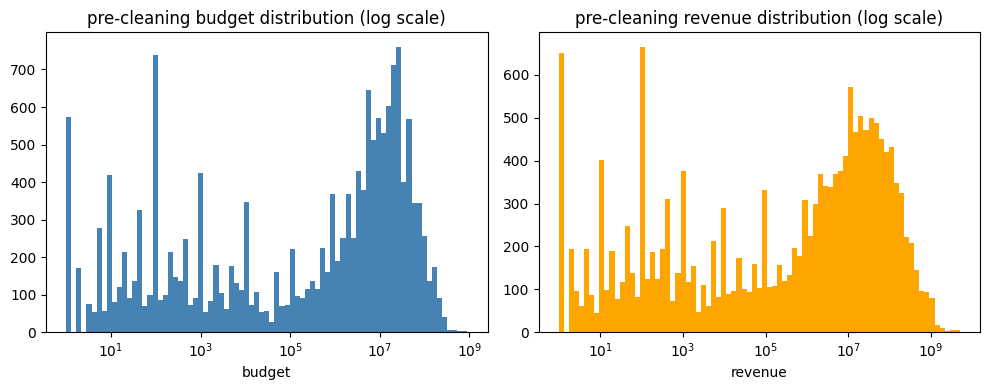

In [10]:
# outlier check before cleaning (released titles with positive financials)
pre_outlier = pre_df[(pre_df["status"] == "Released") & (pre_df["budget"].fillna(0) > 0) & (pre_df["revenue"].fillna(0) > 0)].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(pre_outlier["budget"], bins=np.logspace(np.log10(pre_outlier["budget"].min()), np.log10(pre_outlier["budget"].max()), 80), color="steelblue")
ax[0].set_xscale("log")
ax[0].set_title("pre-cleaning budget distribution (log scale)")
ax[0].set_xlabel("budget")

ax[1].hist(pre_outlier["revenue"], bins=np.logspace(np.log10(pre_outlier["revenue"].min()), np.log10(pre_outlier["revenue"].max()), 80), color="orange")
ax[1].set_xscale("log")
ax[1].set_title("pre-cleaning revenue distribution (log scale)")
ax[1].set_xlabel("revenue")

plt.tight_layout()
plt.show()


### runtime distribution

check runtime spread and long tails that can affect model scaling.


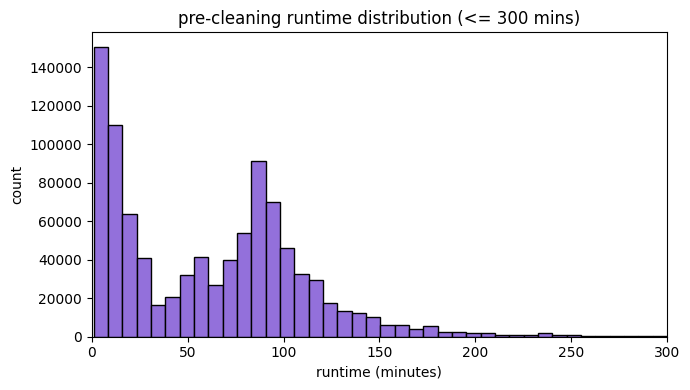

shown rows (<=300 mins): 956,944 / 960,894


In [11]:
# runtime distribution (released titles with valid runtime)
pre_runtime = pre_df[(pre_df["status"] == "Released") & (pre_df["runtime"].fillna(0) > 0)].copy()

# keep a realistic range for visualization only (does not alter the dataset)
runtime_plot = pre_runtime[pre_runtime["runtime"] <= 300]["runtime"]

plt.figure(figsize=(7, 4))
plt.hist(runtime_plot, bins=40, edgecolor="k", color="mediumpurple")
plt.title("pre-cleaning runtime distribution (<= 300 mins)")
plt.xlabel("runtime (minutes)")
plt.ylabel("count")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

print(f"shown rows (<=300 mins): {len(runtime_plot):,} / {len(pre_runtime):,}")


### language distribution

review language imbalance to guide category grouping later.


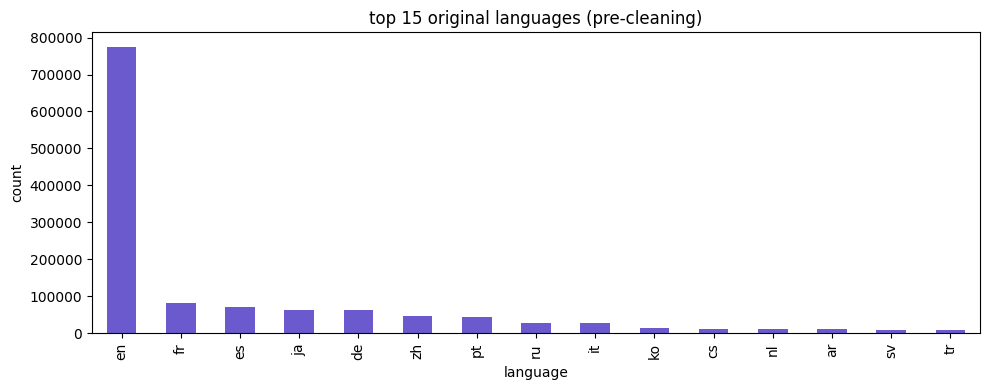

In [12]:
# top original languages
lang_counts = pre_df["original_language"].fillna("unknown").value_counts().head(15)

plt.figure(figsize=(10, 4))
lang_counts.plot(kind="bar", color="slateblue")
plt.title("top 15 original languages (pre-cleaning)")
plt.xlabel("language")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### top production countries

identify dominant producing countries to capture dataset concentration.


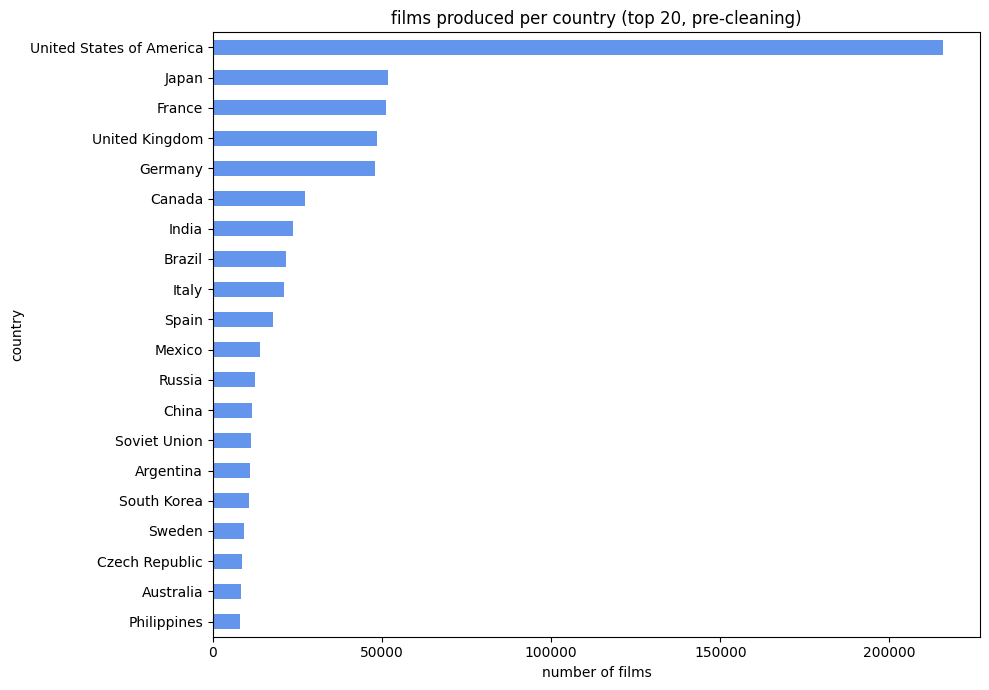

In [13]:
# parse the comma-separated production_countries string into a list per row
production_country_list = pre_df["production_countries"].fillna("").str.split(", ")

# films produced per country
country_counts = production_country_list.explode().dropna()
country_counts = country_counts[country_counts != ""]
country_counts = country_counts.value_counts()

if country_counts.empty:
    print("no production country entries were parsed from the current data sample.")
else:
    top_country_counts = country_counts.head(20).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    top_country_counts.plot(kind="barh", color="cornflowerblue")
    plt.title("films produced per country (top 20, pre-cleaning)")
    plt.xlabel("number of films")
    plt.ylabel("country")
    plt.tight_layout()
    plt.show()


### pre-cleaning eda conclusions

- the raw tmdb table has meaningful missingness in key fields, so cleaning and validity filters are necessary.
- duplicates exist and should be removed using stable ids to avoid biasing the model.
- budget and revenue show heavy right-skew with a low-value cluster, supporting log transforms and minimum-value filtering.
- runtime is also right-skewed, so robust scaling/log-style transforms can improve stability.
- language and production-country distributions are long-tailed, so rare-category grouping should be considered during feature engineering.


# 4) data merging


left join TMDB to IMDB. Keeping all TMDB rows as bse nd add IMDb information where it exists. A left join keeps every TMDB row even if there's no IMDb match. Issue: rows just get NaN for the IMDb columns, which you can handle later.

- use tmdb as base table
- join tmdb `imdb_id` to imdb `tconst`
- keep join diagnostics: row counts and match rate

> note: TMDB v11 has ~1.4M rows including TV/shorts — low overall match rate is expected.
> match rate on movies with valid budget+revenue (after section 5) will be much higher.


## Other aspects to take into account:
- Why only keep the top 3 cast members? The principals file has every cast and crew member — sometimes 50+ people per film. Most of them have no predictive power. The top 3 billed actors (ordering 1-3) are the ones whose names appear in marketing and whose historical track record actually predicts revenue.
- Why pivot cast from long to wide format? The raw principals file has one row per person per film. You need one row per film. Pivoting turns "3 rows for film X" into "1 row with cast_1, cast_2, cast_3 columns."
- Why resolve nconst → actual name? IMDb uses opaque IDs like nm0000093 for people. To compute historical revenue statistics later (section 9.5), you need a human-readable identifier that's consistent across films — the name works, nconst would work too, but names are also readable in outputs.

In [14]:
## 4.1 merge tmdb + crew (directors & writers)
# tmdb is the base table; crew adds director/writer nconst lists per title
base = tmdb.copy()
n_base = len(base)

crew_small = crew[["tconst", "directors", "writers"]].copy()

# left join so all tmdb rows are kept; unmatched rows get NaN for crew columns
merged = base.merge(crew_small, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)  # redundant after join

crew_match = merged["directors"].notna().mean()
print(f"tmdb rows:        {n_base:,}")
print(f"after crew join:  {len(merged):,}")
print(f"crew match rate:  {crew_match:.2%}")  # low overall because ~53% of tmdb rows have no imdb_id

## 4.2 merge top-billed cast from principals
# principals is many-to-one (many cast members per title), so we aggregate first
# keep only actors/actresses ranked 1-3 to avoid exploding rows on join
cast = (
    principals[principals["category"].isin(["actor", "actress"])]
    .sort_values("ordering")
    .groupby("tconst")
    .head(3)
)

# pivot long → wide so each title gets one row with cast_1, cast_2, cast_3 nconst ids
cast["rank"] = cast.groupby("tconst").cumcount() + 1
cast_wide = (
    cast.pivot(index="tconst", columns="rank", values="nconst")
    .rename(columns={1: "cast_1", 2: "cast_2", 3: "cast_3"})
    .reset_index()
)

merged = merged.merge(cast_wide, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)

cast_match = merged["cast_1"].notna().mean()
print(f"after cast join:  {len(merged):,}")
print(f"cast match rate:  {cast_match:.2%}")  # ~81% among rows with imdb_id

## 4.3 resolve nconst → name for director and top cast
# nconst are opaque ids; map them to human-readable names for EDA and features
name_map = names.set_index("nconst")["primaryName"]

def resolve_names(nconst_series):
    return nconst_series.map(name_map)

# directors field can contain a comma-separated list; take only the first (primary) director
merged["director_name"] = resolve_names(merged["directors"].str.split(",").str[0])
merged["cast_1_name"]   = resolve_names(merged["cast_1"])
merged["cast_2_name"]   = resolve_names(merged["cast_2"])
merged["cast_3_name"]   = resolve_names(merged["cast_3"])

print(f"\nfinal shape: {merged.shape}")
merged[["title", "imdb_id", "director_name", "cast_1_name", "cast_2_name", "cast_3_name"]].head()

tmdb rows:        1,417,273
after crew join:  1,417,273
crew match rate:  46.86%
after cast join:  1,417,273
cast match rate:  38.16%

final shape: (1417273, 33)


,title,imdb_id,director_name,cast_1_name,cast_2_name,cast_3_name
0,Inception,tt1375666,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page
1,Interstellar,tt0816692,Christopher Nolan,Matthew McConaughey,Anne Hathaway,Jessica Chastain
2,The Dark Knight,tt0468569,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart
3,Avatar,tt0499549,James Cameron,Sam Worthington,Zoe Saldaña,Sigourney Weaver
4,The Avengers,tt0848228,Joss Whedon,Robert Downey Jr.,Robert Downey Jr.,Chris Evans


In [15]:
# diagnose: how many tmdb rows actually have an imdb_id?
has_imdb = tmdb["imdb_id"].notna() & (tmdb["imdb_id"] != "")
print(f"tmdb rows with imdb_id:    {has_imdb.sum():,} / {len(tmdb):,} ({has_imdb.mean():.2%})")

# of those, how many matched crew?
has_imdb_merged = merged["imdb_id"].notna() & (merged["imdb_id"] != "")
crew_matched = merged["directors"].notna()
print(f"crew match rate (with id): {(crew_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

cast_matched = merged["cast_1"].notna()
print(f"cast match rate (with id): {(cast_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

tmdb rows with imdb_id:    667,649 / 1,417,273 (47.11%)
crew match rate (with id): 99.47%
cast match rate (with id): 81.01%


# 5) data cleaning



- remove invalid/missing budget or revenue rows
- parse dates and normalize schema
- define train-ready base table

### diagnose missing financial data

this quick diagnostic checks missingness patterns in unreleased titles and explains why they should be filtered before modeling.

In [16]:
# display missingness data for columns on the merged table to justify cleaning decisions. 

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = merged[merged["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 

# discover anomalies in financial indicators data (budget and revenue)



Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992632
1          0.000793
100        0.000528
1000       0.000294
10         0.000294
             ...   
1017       0.000029
8000000    0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 103, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904365
100         0.004667
1000        0.004374
500         0.004227
5000        0.003376
              ...   
1597000     0.000029
23914       0.000029
15400000    0.000029
22800000    0.000029
3600000     0.000029
Name: count, Length: 681, dtype: float64


### scope the modeling population

this step keeps only released, non-adult films so the model learns from a consistent population with observable outcomes.

- Filtering only to "Released" status. Films in "Planned" or "In Production" have no revenue by definition. Including them would give the model thousands of rows with a revenue of zero that aren't actually zero — they're just unknown. This would actively mislead the model.

- Why drop adult films? Adult films operate in a completely different market with different distribution, pricing, and audience dynamics. Mixing them into a mainstream revenue prediction model would add noise

- Why filter budget and revenue > 0? TMDB uses 0 as a placeholder for "unknown", not an actual value. A film with $0 budget doesn't mean it was made for free — it means the budget wasn't reported. Training on these would teach the model a false pattern.

- Why filter budget and revenue ≥ $10,000? Even after removing zeros, there are entries like $1 budgets. These are clearly data entry errors — no theatrical film has a $1 budget. $10k is a conservative lower bound for any real film worth modeling.

- Why require a valid release date? Release timing is used as a feature (month, year) and is also essential for computing talent history in the correct chronological order. Without a date, you can't use those features.
- Why require a non-empty overview? Section 9.3 encodes the synopsis using a language model. If there's no synopsis, that row can't contribute to the text modality — and keeping it would mean it gets a zero vector, which is a false signal ("no text" doesn't mean "bad film").
- Why define targets here? You compute y_log_revenue and profitable on the full clean dataset before splitting. This is fine because these are derived from the existing revenue column — you're not computing anything that would leak future information.

In [17]:
df = merged.copy()
print(f"start:                    {len(df):,}")

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = df[df["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 


# keep only released films --> TMDB includes upcoming, in-production, and cancelled
# titles which have no revenue by definition and would just be noise
df = df[df["status"] == "Released"]
print(f"after status filter:      {len(df):,}")

# drop adult content —-> adult films follow different market dynamics and mixing
# them in would hurt the model's ability to learn patterns for mainstream movies
df = df[df["adult"] == False]
print(f"after adult filter:       {len(df):,}")

start:                    1,417,273
Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992632
1          0.000793
100        0.000528
1000       0.000294
10         0.000294
             ...   
1017       0.000029
8000000    0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 103, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904365
100         0.004667
1000        0.004374
500         0.004227
5000        0.003376
              ...   
1597000     0.000029
23914       0.000029
15400000    0.000029
22800000    0.000029
3600000     0.000029
Name: count, Length: 681, dtype: float64
after status filter:      1,366,770
after adult filter:       1,226,686


### keep valid financial signals

this step removes missing-placeholder values and implausibly small numbers to reduce financial noise in training data.

after budget/rev > 0:     16,641


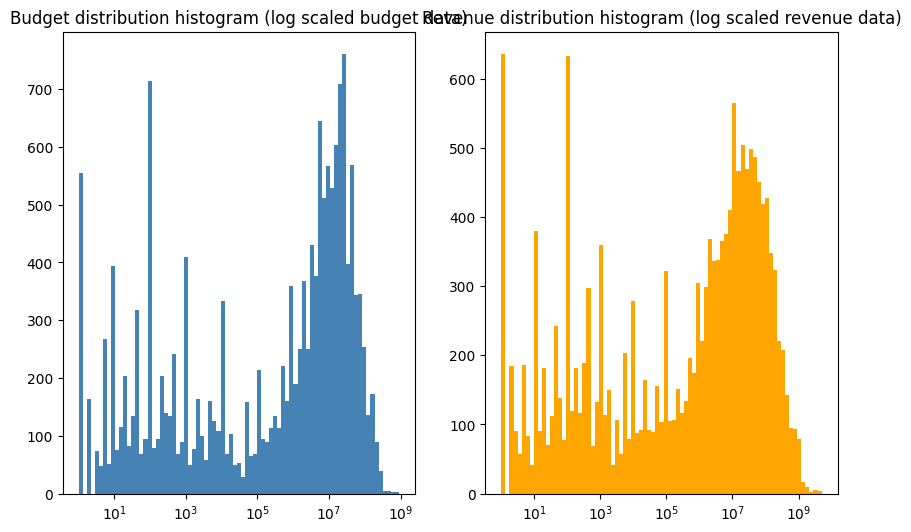

after min $10k filter:    10,654


In [18]:
# require valid budget and revenue --> TMDB uses 0 as a placeholder for "unknown",
# not an actual value, so 0 means missing data rather than a real zero
df = df[df["budget"].fillna(0) > 0]
df = df[df["revenue"].fillna(0) > 0]
print(f"after budget/rev > 0:     {len(df):,}")


# identify significant outliers in budget and revenue so as to justify the minimum $10k filter below 
# data in several orders of magnitude, so to make histogram bins readable, use a log spaced histogram.
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].hist(df["budget"], bins = np.logspace(np.log10(df["budget"].min()), np.log10(df["budget"].max()), 80), color = "steelblue")
ax[0].set_xscale("log")
ax[0].set_title("Budget distribution histogram (log scaled budget data)")
ax[1].hist(df["revenue"], bins = np.logspace(np.log10(df["revenue"].min()), np.log10(df["revenue"].max()), 80), color = "orange")
ax[1].set_xscale("log")
ax[1].set_title("Revenue distribution histogram (log scaled revenue data)")
plt.show()
# the two graphs show a cluster of entries with very low budget and revenue figures, which are likely to be data entry errors. 
# for example, there are around 550 entries with $1 budget. This is highly implausible.


# drop implausibly small values —-> entries like $1 budget or $500 revenue are
# clearly data entry errors; $10k is a conservative lower bound for any real
# theatrical release worth modeling
df = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)]
print(f"after min $10k filter:    {len(df):,}")

### enforce structural completeness

this step ensures required fields exist for downstream features and avoids duplicate movie entries.

In [19]:
# parse and require a valid release date —-> release timing is used as a feature
# (season, year) and is also needed for the temporal cutoff in talent features
# (section 5), so rows without a date can't be used
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
print(f"after date filter:        {len(df):,}")

# drop duplicates on tmdb id —-> some titles appear more than once in TMDB
# (e.g. different regional entries); keep first to avoid inflating the training set
df = df.drop_duplicates(subset=["id"])
print(f"after dedup:              {len(df):,}")

# require a non-empty overview —-> synopsis embeddings are a planned feature group
# (section 5); rows with no overview can't contribute to that modality so we
# drop them now rather than impute
df = df[df["overview"].fillna("").str.strip() != ""]
print(f"after overview filter:    {len(df):,}")

after date filter:        10,149
after dedup:              10,149
after overview filter:    9,950


### define supervised targets

this step creates the final regression and classification targets used by later modeling sections.

In [20]:
# define targets
df["y_log_revenue"] = np.log1p(df["revenue"])
df["profitable"]    = (df["revenue"] > 1.5 * df["budget"]).astype(int)

print(f"\nfinal clean shape: {df.shape}")
print(f"profitable share:  {df['profitable'].mean():.2%}")
df[["title", "release_date", "budget", "revenue", "y_log_revenue", "profitable"]].head()


final clean shape: (9950, 35)
profitable share:  55.88%


,title,release_date,budget,revenue,y_log_revenue,profitable
0,Inception,2010-07-15,160000000,825532764,20.531540,1
1,Interstellar,2014-11-05,165000000,701729206,20.369058,1
2,The Dark Knight,2008-07-16,185000000,1004558444,20.727814,1
3,Avatar,2009-12-15,237000000,2923706026,21.796118,1
4,The Avengers,2012-04-25,220000000,1518815515,21.141197,1


# 6) post-cleaning eda



- validate distributions and relationships on the cleaned modeling dataframe
- this section must run after section 5 (data cleaning)
- eda is intentionally performed on the full cleaned `df` before the train/val/test split: because the split is temporal (sorted by release_date, not random), looking at full-dataset distributions does not leak information about split boundaries — no distribution shift is introduced by this ordering
- this placement also allows catching any remaining data quality issues before committing to the split


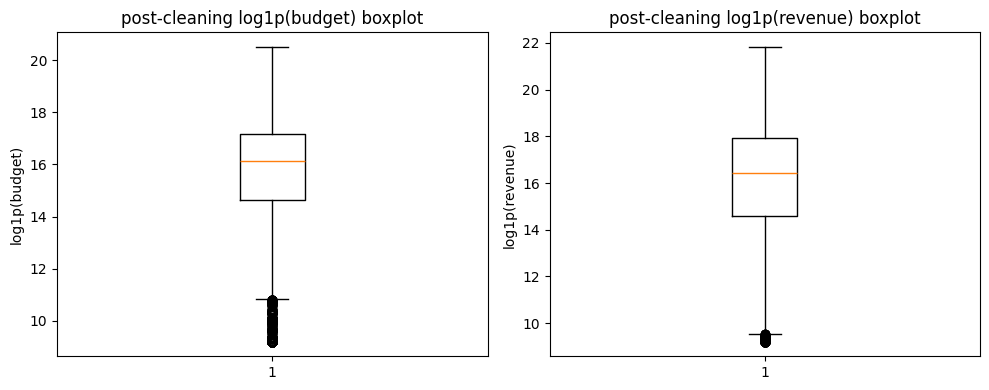

In [21]:
# outlier check after cleaning
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(np.log1p(df["budget"]))
ax[0].set_title("post-cleaning log1p(budget) boxplot")
ax[0].set_ylabel("log1p(budget)")

ax[1].boxplot(df["y_log_revenue"])
ax[1].set_title("post-cleaning log1p(revenue) boxplot")
ax[1].set_ylabel("log1p(revenue)")

plt.tight_layout()
plt.show()


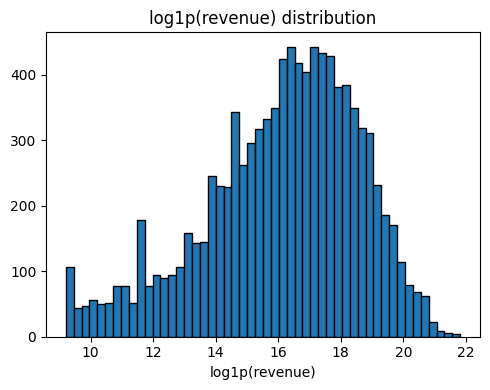

In [22]:
# post-cleaning distribution checks on clean df
plt.figure(figsize=(5, 4))
plt.hist(df["y_log_revenue"], bins=50, edgecolor='k')
plt.title("log1p(revenue) distribution")
plt.xlabel("log1p(revenue)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_revenue_distribution.png", dpi=100)
plt.show()


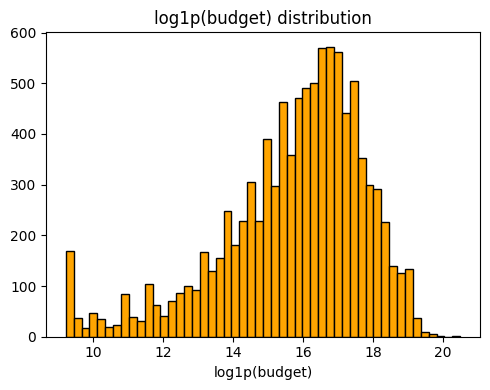

In [23]:
plt.figure(figsize=(5, 4))
plt.hist(np.log1p(df["budget"]), bins=50, edgecolor='k', color='orange')
plt.title("log1p(budget) distribution")
plt.xlabel("log1p(budget)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_budget_distribution.png", dpi=100)
plt.show()


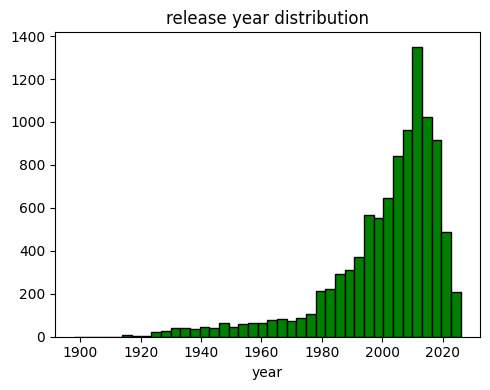

In [24]:
df["release_year"] = df["release_date"].dt.year

plt.figure(figsize=(5, 4))
plt.hist(df["release_year"], bins=40, edgecolor='k', color='green')
plt.title("release year distribution")
plt.xlabel("year")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_release_year_distribution.png", dpi=100)
plt.show()


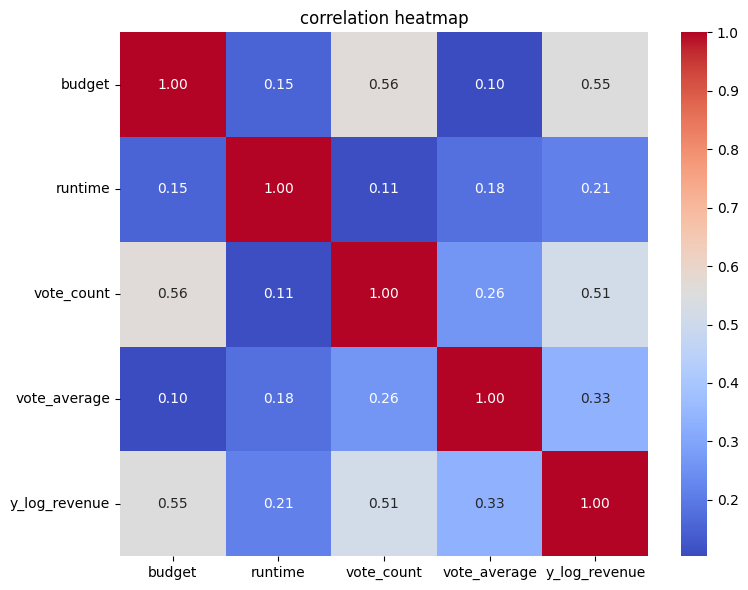

In [25]:
# correlation heatmap — vote columns included here for eda only, not used as features
numeric_cols = ["budget", "runtime", "vote_count", "vote_average", "y_log_revenue"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation.png", dpi=100)
plt.show()


In [26]:
# analysis of relationships between genres and revenue
# genre frequency
df_genres = df.copy() # create a copy of the dataframe for analysis on relationships between genres and other variables
df_genres.dropna(subset = ["genres"], inplace = True)
# find the number of genres that each movie has
df_genres["num_genres"] = df_genres["genres"].str.split(", ").str.len()
# explode the genres column
df_genres["genres"] = df_genres["genres"].str.split(", ")
df_genres = df_genres.explode("genres")
genre_counts = df_genres["genres"].value_counts().head(15)
print("top 15 genres:")
print(genre_counts)

# correlation between genre and revenue for the top 5 genres
# discover whether certain genres tend to have higher revenues
top_genres = genre_counts.head(5).index.tolist()
rows_top_genres = df_genres[df_genres["genres"].isin(top_genres)] # we are interested in finding the movies that belong to the top genres


top 15 genres:
genres
Drama              4623
Comedy             3511
Action             2376
Thriller           2325
Romance            1876
Adventure          1623
Crime              1458
Horror             1094
Family              996
Science Fiction     962
Fantasy             907
Mystery             798
Animation           562
History             507
Music               407
Name: count, dtype: int64


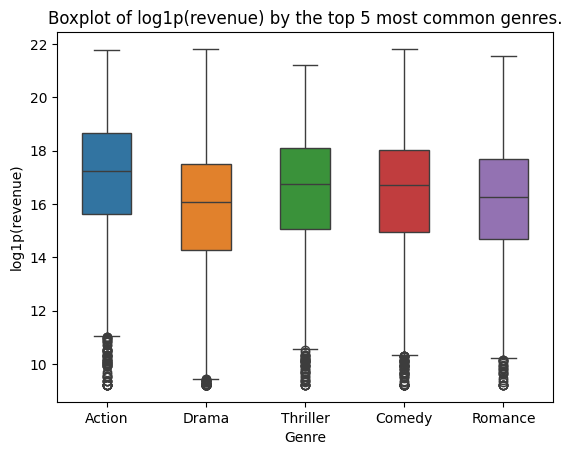

In [27]:
sns.boxplot(data = rows_top_genres, x = "genres", y = "y_log_revenue", hue = "genres", width = 0.5)
plt.title("Boxplot of log1p(revenue) by the top 5 most common genres.")
plt.xlabel("Genre")
plt.ylabel("log1p(revenue)")
plt.show()
# it can be shown that the action genre has the highest 25th percentile, median, and 75th percentile.
# it is likely that the action genre is the most profitable genre on average. there is a potential link between genre and revenue.


In [28]:
# relationships between number of genres and revenue
print("Count of movies by number of genres: ")
print(df_genres["num_genres"].value_counts())
# discover whether the number of genres a movie belongs to will result in an impact on revenue.


Count of movies by number of genres: 
num_genres
3     10095
2      6598
4      4404
1      1747
5      1545
6       294
7        70
11       11
8         8
Name: count, dtype: int64


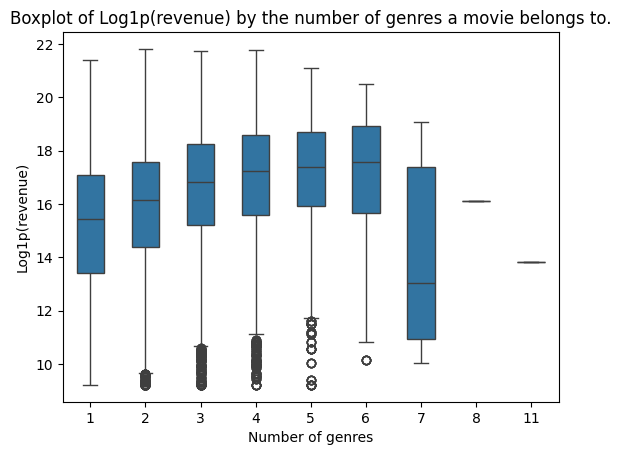

In [29]:
sns.boxplot(data = df_genres, x = "num_genres", y = "y_log_revenue", width = 0.5)
plt.title("Boxplot of Log1p(revenue) by the number of genres a movie belongs to.")
plt.xlabel("Number of genres")
plt.ylabel("Log1p(revenue)")
plt.show()
# up till number of genres = 6, there is a general trend of increasing revenue
# the huge interval between the median and the 75th percentile for genres = 7 is likely due to the fact that there is a small number of movies (70) in total, with some very high earners.
# ignore the movies with > 7 genres since they are outliers and there are very few movies with that many genres.
# overall, the number of genres a movie has seems to be informative, as it can reflect a movie being marketed to a wide range of audiences, stronger push and marketing, etc.


# 7) train / val / test split



split after all cleaning and post-cleaning eda steps.

Why split by time rather than randomly? This is critical. If you split randomly, you might train on a 2019 film and test on a 2018 film. In the real world, you'd never predict a 2018 film after having seen 2019 data. Temporal splitting simulates the real deployment scenario: the model is trained on historical films and asked to predict future ones.


In [30]:
# sort by release date so older films train the model and newer films test it
df_sorted = df.sort_values("release_date").reset_index(drop=True)

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df   = df_sorted.iloc[train_end:val_end].copy()
test_df  = df_sorted.iloc[val_end:].copy()

print(f"train: {len(train_df):,}  ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"val:   {len(val_df):,}  ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"test:  {len(test_df):,}  ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

train: 6,965  (1898–2012)
val:   1,492  (2012–2017)
test:  1,493  (2017–2026)


# 8) data leakage analysis

- define the pre-release information boundary
- columns like `vote_average`, `vote_count`, `popularity` reflect post-release audience response — exclude from main features
- run a leakage demonstration: train with vs without these columns to quantify their inflation effect

The demonstration: you train two Ridge models — one with and without these columns — and show that the leaked version has a dramatically higher R². This difference is entirely artificial, which proves these features can't be used.

In [31]:
# columns known before a film's release date — safe to use as features
PRE_RELEASE_COLS = [
    "budget", "runtime", "original_language",
    "genres", "production_companies", "production_countries",
    "release_date",   # used to derive timing features
    "overview",       # for synopsis embeddings
    "poster_path",    # for poster embeddings
    "director_name", "cast_1_name", "cast_2_name", "cast_3_name",
    "directors", "cast_1", "cast_2", "cast_3",
]

# only known after release — must not be used as predictive features
POST_RELEASE_COLS = ["vote_average", "vote_count", "popularity"]

print("post-release columns excluded from main feature set:")
for col in POST_RELEASE_COLS:
    print(f"  {col}")

# leakage demonstration: compare r2 with and without post-release columns
demo_safe   = ["budget", "runtime"]
demo_leaked = ["budget", "runtime", "vote_count", "vote_average", "popularity"]

def demo_r2(cols):
    _train = train_df[cols + ["y_log_revenue"]].dropna()
    _val   = val_df[cols + ["y_log_revenue"]].dropna()
    model  = Ridge().fit(_train[cols], _train["y_log_revenue"])
    return r2_score(_val["y_log_revenue"], model.predict(_val[cols]))

print(f"\nr2 without leakage cols: {demo_r2(demo_safe):.3f}")
print(f"r2 WITH leakage cols:    {demo_r2(demo_leaked):.3f}")
print("→ inflated r2 confirms these are post-release signals, not predictive features")

post-release columns excluded from main feature set:
  vote_average
  vote_count
  popularity

r2 without leakage cols: 0.358
r2 WITH leakage cols:    0.475
→ inflated r2 confirms these are post-release signals, not predictive features


# 9) feature engineering

### 9.1 structured metadata
- `log_budget`: log1p-transforms budget to compress the heavy right tail and linearise the budget–revenue relationship
- `runtime`: missing values imputed with the train-set median (zero-fill would create a spurious "no-runtime" signal)
- `release_month`, `release_year`: capture seasonal box-office patterns and inflation/market-growth trends over time
- `is_english`: binary flag — english is the dominant language category (>50 % of training titles); full cardinality encoding adds noise for rare languages
- `is_us_production`: binary flag — us productions dominate the dataset and sit in systematically higher revenue brackets (confirmed in eda, section 3)
- `num_genres`: count of genres per title — eda (section 6) showed a positive trend with revenue up to ~6 genres, likely reflecting wider audience targeting and larger marketing pushes
- `is_sequel`: binary flag — whether the film belongs to a collection (franchise/sequel); derived from TMDB`s `belongs_to_collection` field, one of the strongest pre-release box office predictors
- `collection_size`: number of films in the same collection; standalone films get 1; larger franchises signal established audience demand


StandardScaler: Applied after all feature construction. Ridge regression (and any distance-based model) is sensitive to feature scale — a feature measured in millions of dollars would completely dominate a binary 0/1 flag. Scaling puts everything on the same standard deviation scale. Critically, the scaler is fit only on training data. If you fit it on all data, you would incorporate the mean and standard deviation of the val/test distributions — leakage.

In [32]:
# scaler is fit on train only — applying to val/test avoids leaking their distribution statistics

# impute missing runtime with the train-set median before scaling:
# fillna(0) would introduce a spurious "zero-runtime" bin that tree models would split on;
# the median is a robust central estimate that keeps the imputed value in the distribution core
train_median_runtime = train_df["runtime"].median()
for split in [train_df, val_df, test_df]:
    split["runtime"] = split["runtime"].fillna(train_median_runtime)

# sequel flag — TMDB v11 does not include belongs_to_collection, so we infer from two signals:
# 1. keywords column: contains the term "sequel" for many franchise entries
# 2. title pattern: ends with or contains a number or roman numeral (e.g. "Thor 2", "Rocky III")
import re
_sequel_pattern = re.compile(
    r"(2|3|4|5|6|7|8|9|II|III|IV|VI|VII|VIII|IX|X|Part\s+\d|Chapter\s+\d)",
    re.IGNORECASE
)
df_sorted["is_sequel"] = (
    df_sorted["keywords"].fillna("").str.contains("sequel", case=False, regex=False) |
    df_sorted["title"].fillna("").apply(lambda t: bool(_sequel_pattern.search(t)))
).astype(int)

for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    split["is_sequel"] = df_sorted["is_sequel"].iloc[sl].values

for split in [train_df, val_df, test_df]:
    # log1p compresses the multi-order-of-magnitude budget range and linearises
    # the relationship with log-revenue (both are now roughly on the same scale)
    split["log_budget"] = np.log1p(split["budget"])

    split["release_month"] = split["release_date"].dt.month
    # release_year already on df from the eda cell — no need to recompute

    # binary english flag rather than full language one-hot: english accounts for >50% of
    # training titles and is the dominant revenue-correlated category; encoding all rare
    # languages individually would add noise with minimal signal
    split["is_english"] = (split["original_language"] == "en").astype(int)

    # us productions dominate the dataset and sit in higher revenue brackets (see eda);
    # a binary flag captures this cleanly without encoding the full country list
    split["is_us_production"] = (
        split["production_countries"].fillna("").str.contains("United States of America", regex=False)
    ).astype(int)

    # genre count: eda (section 6) showed revenue increases monotonically up to ~6 genres;
    # wider genre coverage likely reflects larger marketing scope and audience targeting
    split["num_genres"] = split["genres"].fillna("").apply(
        lambda x: len(x.split(", ")) if x.strip() else 0
    )

structured_cols = [
    "log_budget", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres", "is_sequel",
]

scaler_struct  = StandardScaler()
X_struct_train = scaler_struct.fit_transform(train_df[structured_cols])
X_struct_val   = scaler_struct.transform(val_df[structured_cols])
X_struct_test  = scaler_struct.transform(test_df[structured_cols])

print(f"9.1 structured features: {X_struct_train.shape}")
print(f"  cols: {structured_cols}")
print(f"  sequel share (train): {train_df['is_sequel'].mean():.1%}")

9.1 structured features: (6965, 8)
  cols: ['log_budget', 'runtime', 'release_month', 'release_year', 'is_english', 'is_us_production', 'num_genres', 'is_sequel']
  sequel share (train): 2.4%


### 9.2 genre indicators
- one-hot encode comma-separated genres (handcrafted)
- genre vocabulary fixed on train to prevent unseen-genre columns leaking test-set schema


In [33]:
def genre_dummies(split_df):
    return split_df["genres"].fillna("").str.get_dummies(sep=", ")

g_train = genre_dummies(train_df)
g_val   = genre_dummies(val_df)
g_test  = genre_dummies(test_df)

genre_cols    = g_train.columns.tolist()  # only genres seen in training
X_genre_train = g_train.values
X_genre_val   = g_val.reindex(columns=genre_cols, fill_value=0).values
X_genre_test  = g_test.reindex(columns=genre_cols, fill_value=0).values

print(f"9.2 genre features: {X_genre_train.shape}  —  {genre_cols}")

9.2 genre features: (6965, 19)  —  ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


### 9.3 synopsis embeddings
- encode `overview` text with a pretrained sentence transformer (all-MiniLM-L6-v2, 384-dim)
- captures thematic content, tone, and premise — information unavailable from structured fields
- cache to disk — only computed once


In [34]:
SYNOPSIS_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings.npy"
SYNOPSIS_ID_PATH  = OUTPUT_DIR / "synopsis_ids.npy"

if SYNOPSIS_EMB_PATH.exists():
    synopsis_embs = np.load(SYNOPSIS_EMB_PATH)
    synopsis_ids  = np.load(SYNOPSIS_ID_PATH)
    print(f"loaded cached synopsis embeddings: {synopsis_embs.shape}")
else:
    # only import torch if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model      = SentenceTransformer("all-MiniLM-L6-v2")
    overviews     = df_sorted["overview"].fillna("").tolist()
    synopsis_embs = st_model.encode(overviews, batch_size=64, show_progress_bar=True)
    synopsis_ids  = df_sorted["id"].values
    np.save(SYNOPSIS_EMB_PATH, synopsis_embs)
    np.save(SYNOPSIS_ID_PATH, synopsis_ids)
    print(f"computed and cached synopsis embeddings: {synopsis_embs.shape}")

# align embeddings back to each split by movie id
def align_emb(split_df, all_ids, all_embs):
    if all_embs.ndim < 2 or all_embs.shape[0] == 0:
        raise ValueError(
            f"embeddings array has shape {all_embs.shape} — "
            "delete the cache file and re-run the embedding cell to regenerate it"
        )
    id_to_emb = dict(zip(all_ids, all_embs))
    dim = all_embs.shape[1]
    return np.array([id_to_emb.get(i, np.zeros(dim)) for i in split_df["id"]])

X_synopsis_train = align_emb(train_df, synopsis_ids, synopsis_embs)
X_synopsis_val   = align_emb(val_df,   synopsis_ids, synopsis_embs)
X_synopsis_test  = align_emb(test_df,  synopsis_ids, synopsis_embs)

print(f"9.3 synopsis embeddings: {X_synopsis_train.shape}")

loaded cached synopsis embeddings: (9950, 384)
9.3 synopsis embeddings: (6965, 384)


### 9.4 poster embeddings
- download poster images from TMDB and encode with ResNet18 (classification head removed → 512-dim)
- captures visual style, colour palette, and genre signals in the poster art
- cache to disk — slow on first run (~10–30 min for 10k images)

A film's poster encodes genre signals, color palette, and visual style. ResNet18 (a convolutional neural network pretrained on ImageNet) processes each poster and outputs a 512-dimensional feature vector. The classification head is removed (resnet.fc = Identity()) so you get the raw visual features rather than ImageNet class probabilities. Why rate-limit with time.sleep? TMDB's API throttles requests. Without a delay, you'd get blocked partway through downloading 10,000 posters.



In [ ]:
# CLIP (openai/clip-vit-base-patch32) replaces ResNet18
# ResNet18 was trained on ImageNet object classification — its features don't capture
# cinematic concepts. CLIP is trained on image-text pairs and learns visual features
# aligned to language ("action movie aesthetic", "prestige drama"), making it more
# relevant for predicting revenue from a poster.
# output: 512-dim embeddings per poster, cached to disk

import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO

# separate cache path from old ResNet18 embeddings to avoid loading stale data
POSTER_EMB_PATH = OUTPUT_DIR / "poster_embeddings_clip.npy"
POSTER_ID_PATH  = OUTPUT_DIR / "poster_ids_clip.npy"
CHECKPOINT_PATH = OUTPUT_DIR / "poster_checkpoint_clip.npz"

if POSTER_EMB_PATH.exists():
    poster_embs = np.load(POSTER_EMB_PATH)
    poster_ids  = np.load(POSTER_ID_PATH)
    # guard against a previously cached empty/corrupt file
    if poster_embs.ndim < 2 or poster_embs.shape[0] == 0:
        print("cached file is empty or corrupt — deleting and regenerating...")
        POSTER_EMB_PATH.unlink()
        POSTER_ID_PATH.unlink(missing_ok=True)
    else:
        print(f"loaded cached CLIP poster embeddings: {poster_embs.shape}")

if not POSTER_EMB_PATH.exists():
    from concurrent.futures import ThreadPoolExecutor, as_completed

    if CHECKPOINT_PATH.exists():
        ckpt        = np.load(CHECKPOINT_PATH)
        poster_vecs = list(ckpt["vecs"])
        valid_ids   = list(ckpt["ids"])
        done_ids    = set(valid_ids)
        print(f"resuming from checkpoint: {len(done_ids)} done")
    else:
        poster_vecs = []
        valid_ids   = []
        done_ids    = set()

    clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.eval()

    N_WORKERS  = 16   # parallel download threads
    BATCH_SIZE = 64   # images per clip inference batch
    SAVE_EVERY = 500  # checkpoint interval

    rows = df_sorted[df_sorted["poster_path"].notna()]
    rows = rows[~rows["id"].isin(done_ids)]
    todo = [(row["id"], f"https://image.tmdb.org/t/p/w342{row['poster_path']}")
            for _, row in rows.iterrows()]

    def fetch(id_url):
        movie_id, url = id_url
        try:
            resp = requests.get(url, timeout=8)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
            return movie_id, img
        except Exception as e:
            return movie_id, e

    failed      = 0
    first_errors = []
    batch_imgs, batch_ids = [], []

    def encode_and_store(imgs, ids):
        inputs = clip_processor(images=imgs, return_tensors="pt", padding=True)
        with torch.no_grad():
            vecs = clip_model.get_image_features(**inputs).numpy()
        poster_vecs.extend(vecs)
        valid_ids.extend(ids)

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(fetch, item): item for item in todo}
        for done_count, fut in enumerate(as_completed(futures), 1):
            movie_id, result = fut.result()
            if isinstance(result, Exception):
                failed += 1
                if len(first_errors) < 3:
                    first_errors.append(f"  {movie_id}: {result}")
            else:
                batch_imgs.append(result)
                batch_ids.append(movie_id)

            # encode when batch is full
            if len(batch_imgs) == BATCH_SIZE:
                encode_and_store(batch_imgs, batch_ids)
                batch_imgs, batch_ids = [], []

            if done_count % SAVE_EVERY == 0:
                if batch_imgs:                          # flush partial batch first
                    encode_and_store(batch_imgs, batch_ids)
                    batch_imgs, batch_ids = [], []
                np.savez(CHECKPOINT_PATH,
                         vecs=np.array(poster_vecs),
                         ids=np.array(valid_ids))
                print(f"  [{done_count}/{len(todo)}] {len(valid_ids)} ok / {failed} failed")

    # flush remaining images
    if batch_imgs:
        encode_and_store(batch_imgs, batch_ids)

    for msg in first_errors:
        print(msg)
    print(f"loop done: {len(poster_vecs)} ok / {failed} failed")

    if not poster_vecs:
        raise RuntimeError(
            "no poster images could be downloaded — check network/TMDB access. "
            "First errors shown above."
        )

    poster_embs = np.array(poster_vecs)
    poster_ids  = np.array(valid_ids)
    np.save(POSTER_EMB_PATH, poster_embs)
    np.save(POSTER_ID_PATH,  poster_ids)
    print(f"done: {poster_embs.shape}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

### 9.5 talent features
- `director_hist_log_rev`: expanding median of the director's prior films' log-revenue, ordered by release date
- `cast1_hist_log_rev`: same for the lead actor/actress
- talent track-record is one of the strongest pre-release signals used in real industry forecasting (greenlight models, p&a budgeting)
- expanding median (not mean) is used to be robust against a single breakout hit inflating the estimate. If a director made 10 small films then one $500M blockbuster, the mean would shoot up dramatically and misrepresent their typical earning power. The median is robust to this.
- `shift(1)` ensures each film is excluded from its own statistic — no target leakage
- films with no prior credits receive the train-set global median as a neutral prior

In [36]:
## 9.5 talent features — director and lead-cast historical revenue
# same expanding-median approach as before, but cold-start films (no prior credits)
# now receive a Bayesian shrinkage prior instead of the global median
# prior = 0.7 * genre_mean + 0.3 * global_mean
# this is more informative: an unknown action director is likely to earn more
# than an unknown documentary director; conflating them with the same flat fill
# value was misleading (~47.8% of films had no prior credits)

# step 1: expanding median per director and lead actor
for entity_col, out_col in [
    ("director_name", "director_hist_log_rev"),
    ("cast_1_name",   "cast1_hist_log_rev"),
]:
    df_sorted[out_col] = (
        df_sorted
        .groupby(entity_col)["y_log_revenue"]
        .transform(lambda x: x.shift(1).expanding().median())
    )

# step 2: build Bayesian shrinkage prior from training data only
# computing genre means on train only avoids leaking val/test distributions
train_global_mean = df_sorted.iloc[:train_end]["y_log_revenue"].mean()

genre_means = (
    df_sorted.iloc[:train_end]
    .assign(genre=lambda d: d["genres"].str.split(", "))
    .explode("genre")
    .groupby("genre")["y_log_revenue"]
    .mean()
)

# use first-listed genre as the primary genre proxy for each film
df_sorted["primary_genre"] = df_sorted["genres"].str.split(", ").str[0]

# map genre mean; unseen genres (val/test genres not in train) fall back to global mean
df_sorted["genre_mean"] = df_sorted["primary_genre"].map(genre_means).fillna(train_global_mean)

# shrinkage prior: 70% genre mean, 30% global mean
# unknown-genre films converge smoothly to global; well-represented genres get a tighter prior
df_sorted["talent_prior"] = 0.7 * df_sorted["genre_mean"] + 0.3 * train_global_mean

# step 3: fill cold-start NaNs row-by-row with their genre-specific prior
for out_col in ["director_hist_log_rev", "cast1_hist_log_rev"]:
    mask = df_sorted[out_col].isna()
    df_sorted.loc[mask, out_col] = df_sorted.loc[mask, "talent_prior"]

# step 4: propagate back to splits
talent_cols = ["director_hist_log_rev", "cast1_hist_log_rev"]
for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    for col in talent_cols:
        split[col] = df_sorted[col].iloc[sl].values

# scale on train only — same discipline as all other feature groups
scaler_talent  = StandardScaler()
X_talent_train = scaler_talent.fit_transform(train_df[talent_cols])
X_talent_val   = scaler_talent.transform(val_df[talent_cols])
X_talent_test  = scaler_talent.transform(test_df[talent_cols])

print(f"9.5 talent features: {X_talent_train.shape}")
print(f"  train global mean:  {train_global_mean:.3f}")
print(f"  genre means range:  {genre_means.min():.3f} – {genre_means.max():.3f}")
print(f"  remaining NaNs after fill: {df_sorted[['director_hist_log_rev', 'cast1_hist_log_rev']].isna().sum().sum()}")

9.5 talent features: (6965, 2)
  train global mean:  16.161
  genre means range:  14.443 – 17.249
  remaining NaNs after fill: 0


# 10) multimodal fusion


- early fusion: concatenate all modality matrices into one design matrix
- this lets any downstream model learn cross-modal interactions
- individual modality matrices are kept separate for the ablation study (section 13)

Why put talent features before embeddings? Tree-based models like LightGBM build splits greedily. Placing the low-dimensional, high-signal features (talent: 2 columns) before the high-dimensional embeddings (synopsis: 384 columns, poster: 512 columns) means the model finds the most informative splits early. In practice the ordering matters less for gradient boosting, but it's a reasonable convention.

In [37]:
# run this before the fusion cell if X_poster_train is not defined
poster_embs = np.load(POSTER_EMB_PATH)
poster_ids  = np.load(POSTER_ID_PATH)

X_poster_train = align_emb(train_df, poster_ids, poster_embs)
X_poster_val   = align_emb(val_df,   poster_ids, poster_embs)
X_poster_test  = align_emb(test_df,  poster_ids, poster_embs)

print(f"poster embeddings aligned: {X_poster_train.shape}")

IndexError: tuple index out of range

In [ ]:
# early fusion: horizontally stack all modality feature matrices
# order: structured | genre | talent | synopsis | poster
# talent is placed before the high-dimensional embeddings so tree-based models can
# exploit the low-cardinality tabular signal in early splits without it being
# "diluted" by hundreds of embedding dimensions appearing first in the feature space
X_train_full = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train, X_poster_train])
X_val_full   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val,   X_poster_val])
X_test_full  = np.hstack([X_struct_test,  X_genre_test,  X_talent_test,  X_synopsis_test,  X_poster_test])

y_train = train_df["y_log_revenue"].values
y_val   = val_df["y_log_revenue"].values
y_test  = test_df["y_log_revenue"].values

print(f"full fused feature matrix: {X_train_full.shape}")
print(f"  structured: {X_struct_train.shape[1]} dims")
print(f"  genre:      {X_genre_train.shape[1]} dims")
print(f"  talent:     {X_talent_train.shape[1]} dims")
print(f"  synopsis:   {X_synopsis_train.shape[1]} dims")
print(f"  poster:     {X_poster_train.shape[1]} dims")

full fused feature matrix: (6965, 924)
  structured: 7 dims
  genre:      19 dims
  talent:     2 dims
  synopsis:   384 dims
  poster:     512 dims


In [ ]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 10045 MB
X_train_full shape: (6965, 924)
X_train_full size in memory: 49.1 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


In [ ]:
import gc
import torch

# free embedding models
try:
    del st_model
    print("freed st_model")
except NameError:
    print("st_model already gone")

try:
    del resnet
    print("freed resnet")
except NameError:
    print("resnet already gone")

# free raw embedding arrays
try:
    del synopsis_embs, synopsis_ids
    print("freed synopsis arrays")
except NameError:
    print("synopsis arrays already gone")

try:
    del poster_embs, poster_ids
    print("freed poster arrays")
except NameError:
    print("poster arrays already gone")

# free pytorch cache if it was used
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# force full garbage collection
gc.collect()

# check result
process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024
print(f"\nmemory after cleanup: {mem_mb:.0f} MB")

st_model already gone
resnet already gone
freed synopsis arrays
freed poster arrays

memory after cleanup: 10045 MB


In [ ]:
import sys

# find the largest objects currently in memory
objects = [(name, sys.getsizeof(obj)) 
           for name, obj in globals().items() 
           if not name.startswith('_')]

objects.sort(key=lambda x: x[1], reverse=True)

print("top 20 largest objects in memory:")
for name, size in objects[:20]:
    print(f"  {name:<40} {size / 1024 / 1024:.1f} MB")

top 20 largest objects in memory:
  principals                               27540.9 MB
  cast                                     5190.7 MB
  names                                    5119.9 MB
  name_map                                 2296.4 MB
  crew                                     2107.7 MB
  crew_small                               2107.7 MB
  merged                                   2055.6 MB
  tmdb                                     1525.4 MB
  pre_df                                   1525.4 MB
  base                                     1525.4 MB
  cast_wide                                1430.9 MB
  pre_runtime                              1124.6 MB
  production_country_list                  130.0 MB
  X_train_full                             49.1 MB
  Xtr                                      49.1 MB
  df_genres                                48.8 MB
  unreleased                               46.9 MB
  X_train_v2                               45.0 MB
  synopsis_embs_v2    

In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"total RAM:     {ram.total / 1024**3:.1f} GB")
print(f"available RAM: {ram.available / 1024**3:.1f} GB")
print(f"used:          {ram.used / 1024**3:.1f} GB")
print(f"percent used:  {ram.percent}%")

total RAM:     36.0 GB
available RAM: 13.4 GB
used:          15.9 GB
percent used:  62.8%


# 11) baseline model

- ridge regression on structured metadata only (no embeddings, no talent features)
- establishes the performance floor that more complex models must beat

In [ ]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 16665 MB
X_train_full shape: (6965, 924)
X_train_full size in memory: 49.1 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


In [ ]:
baseline_cols = ["budget", "runtime"]

train_base = train_df[baseline_cols + ["y_log_revenue"]].dropna()
val_base   = val_df[baseline_cols + ["y_log_revenue"]].dropna()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_base[baseline_cols])
X_val   = scaler.transform(val_base[baseline_cols])

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, train_base["y_log_revenue"])

y_pred = baseline_model.predict(X_val)
y_true = val_base["y_log_revenue"]

print("baseline — ridge on budget + runtime:")
print(f"  rmse: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  mae:  {mean_absolute_error(y_true, y_pred):.4f}")
print(f"  r2:   {r2_score(y_true, y_pred):.4f}")

baseline — ridge on budget + runtime:
  rmse: 2.1672
  mae:  1.6841
  r2:   0.3584


# 12) evaluation metrics



helper functions `evaluate_regression` and `evaluate_classification` are defined in the **setup cell (cell 1)** at the top of the notebook, so they are available throughout all sections without re-definition.

- primary regression metrics: rmse, mae, r2 on log-revenue
- secondary classification metrics: precision, recall, f1, auc on profitability label
- all metrics computed on val set during development; test set used only for final evaluation

> **note on classification auc**: the `evaluate_classification` function expects a continuous score (predicted log-revenue converted to a probability), not a hard 0/1 array. In the final evaluation section (17), we derive a probability proxy from the regression score before passing it in.


- RMSE (root mean squared error): penalizes large errors heavily (because it squares them). Good at catching cases where the model occasionally makes catastrophically wrong predictions.
- MAE (mean absolute error): treats all errors equally. More interpretable — "on average, we're off by X log-revenue units."
- R²: measures what fraction of revenue variance the model explains. 0 means the model is no better than predicting the mean; 1 means perfect. Gives you a quick sense of overall quality.



# 13) model selection + lightgbm



we compare ridge regression against lightgbm on the full feature matrix.
lightgbm uses early stopping on the val set (patience=50 rounds).

Why early stopping with patience=50? You train up to 1000 trees, but after each tree you check performance on the val set. If the val performance hasn't improved for 50 consecutive trees, you stop — the model is starting to overfit. This prevents you from having to manually tune n_estimators.


Why compare with and without poster embeddings? Poster embeddings are 512 dimensions of ResNet features. They're expensive to compute and might add noise rather than signal. Comparing LightGBM with/without them tells you whether the poster modality actually helps the best model, not just Ridge.



In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    random_state=SEED,
    n_jobs=-1,
)
lgb_model.fit(
    X_train_full, y_train,
    eval_set=[(X_val_full, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM full feature matrix (val):")
lgb_val_results = evaluate_regression(
    y_val, lgb_model.predict(X_val_full), label="LightGBM full"
)

# also compare without poster embeddings
X_e3_train = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train])
X_e3_val   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])

lgb_no_poster = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, min_child_samples=50,
    subsample=0.8, random_state=SEED, n_jobs=-1,
)
lgb_no_poster.fit(
    X_e3_train, y_train,
    eval_set=[(X_e3_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM no poster (val):")
evaluate_regression(y_val, lgb_no_poster.predict(X_e3_val), label="LightGBM no poster")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.59415
[200]	valid_0's l2: 2.56915
[300]	valid_0's l2: 2.5571
[400]	valid_0's l2: 2.55686
Early stopping, best iteration is:
[357]	valid_0's l2: 2.55526

LightGBM full feature matrix (val):
LightGBM full — rmse: 1.5985 | mae: 1.2119 | r2: 0.6509


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.6275
[200]	valid_0's l2: 2.61406
Early stopping, best iteration is:
[152]	valid_0's l2: 2.6102

LightGBM no poster (val):
LightGBM no poster — rmse: 1.6156 | mae: 1.2188 | r2: 0.6434


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.6156114590597648),
 'mae': 1.218797834379826,
 'r2': 0.6434301511040719}

# 14) ablation study



Removing components one at a time to measure each one's contribution.Here, you start with structured features only and add modalities one by one: +genre, +talent, +synopsis, +poster.

Why use Ridge (not LightGBM) for the ablation? Ridge is a fixed, simple model with no tuning. If you used LightGBM with different hyperparameters for each experiment, you wouldn't know if the performance change came from the new features or from the different model configuration. Ridge isolates the feature contribution cleanly.


- fixed temporal split and evaluation protocol
- experiment matrix comparing modality contributions:
  - e0: structured only (baseline)
  - e1: + genre indicators
  - e2: + synopsis embeddings
  - e3: + poster embeddings
  - e4: all modalities combined

In [ ]:
ablation_results = {}

experiments = [
    ("E0 structured only",
        np.hstack([X_struct_train]),
        np.hstack([X_struct_val])),
    ("E1 +genre",
        np.hstack([X_struct_train, X_genre_train]),
        np.hstack([X_struct_val,   X_genre_val])),
    ("E2 +talent",
        np.hstack([X_struct_train, X_genre_train, X_talent_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val])),
    ("E3 +synopsis",
        np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])),
    ("E4 +poster (full)",
        X_train_full,
        X_val_full),
]

for name, Xtr, Xv in experiments:
    model = Ridge()
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xv)
    ablation_results[name] = evaluate_regression(y_val, y_pred, label=name)

# summary table
print("\n=== ablation summary ===")
prev_r2 = None
for name, res in ablation_results.items():
    delta = f"+{res['r2'] - prev_r2:.3f}" if prev_r2 is not None else "—"
    print(f"{name:30s}  r2={res['r2']:.3f}  delta={delta}")
    prev_r2 = res["r2"]

E0 structured only — rmse: 1.6922 | mae: 1.3097 | r2: 0.6088
E1 +genre — rmse: 1.6718 | mae: 1.2873 | r2: 0.6182
E2 +talent — rmse: 1.6565 | mae: 1.2721 | r2: 0.6252
E3 +synopsis — rmse: 1.6488 | mae: 1.2644 | r2: 0.6287
E4 +poster (full) — rmse: 1.6954 | mae: 1.3089 | r2: 0.6073

=== ablation summary ===
E0 structured only              r2=0.609  delta=—
E1 +genre                       r2=0.618  delta=+0.009
E2 +talent                      r2=0.625  delta=+0.007
E3 +synopsis                    r2=0.629  delta=+0.003
E4 +poster (full)               r2=0.607  delta=+-0.021


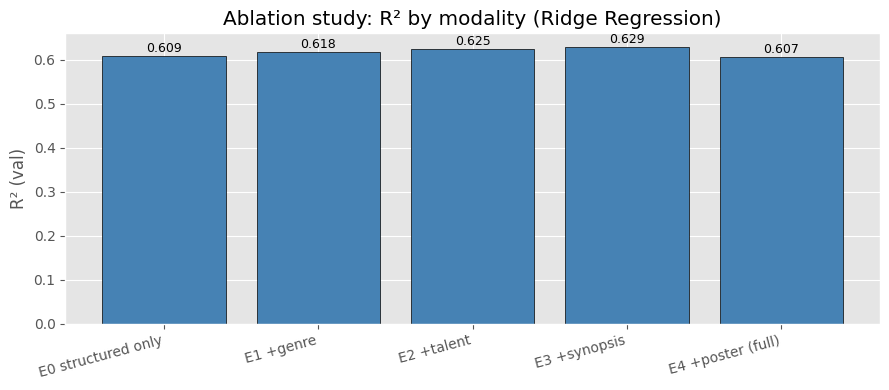

In [ ]:
# ablation bar chart — useful figure for the report
names  = list(ablation_results.keys())
r2_vals = [ablation_results[n]["r2"] for n in names]

plt.figure(figsize=(9, 4))
bars = plt.bar(names, r2_vals, color="steelblue", edgecolor="k")
plt.ylabel("R² (val)")
plt.title("Ablation study: R² by modality (Ridge Regression)")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_r2_bar.png", dpi=100)
plt.show()


# 15) interpretability with shap


We use shap treeexplainer to understand which features drive predictions in the best lightgbm model.

What is SHAP? SHAP (SHapley Additive exPlanations) is a method from game theory that assigns each feature a contribution to each individual prediction. For a film predicted to earn $200M, SHAP tells you: "budget contributed +2.1, director history contributed +1.3, being an English film contributed +0.4..."

Why TreeExplainer specifically? It's an exact, efficient algorithm for tree-based models (like LightGBM). It's much faster than the model-agnostic alternatives and gives exact values rather than approximations.

Why subsample to 1000 rows? Computing SHAP values for every validation example would take a long time for a model with 900+ features. 1000 rows gives stable global importance estimates without the wait.

Why a beeswarm plot as well as a bar plot? The bar plot shows average feature importance. The beeswarm shows the distribution of each feature's impact — you can see whether a feature always pushes predictions up, or whether it sometimes helps and sometimes hurts depending on its value.

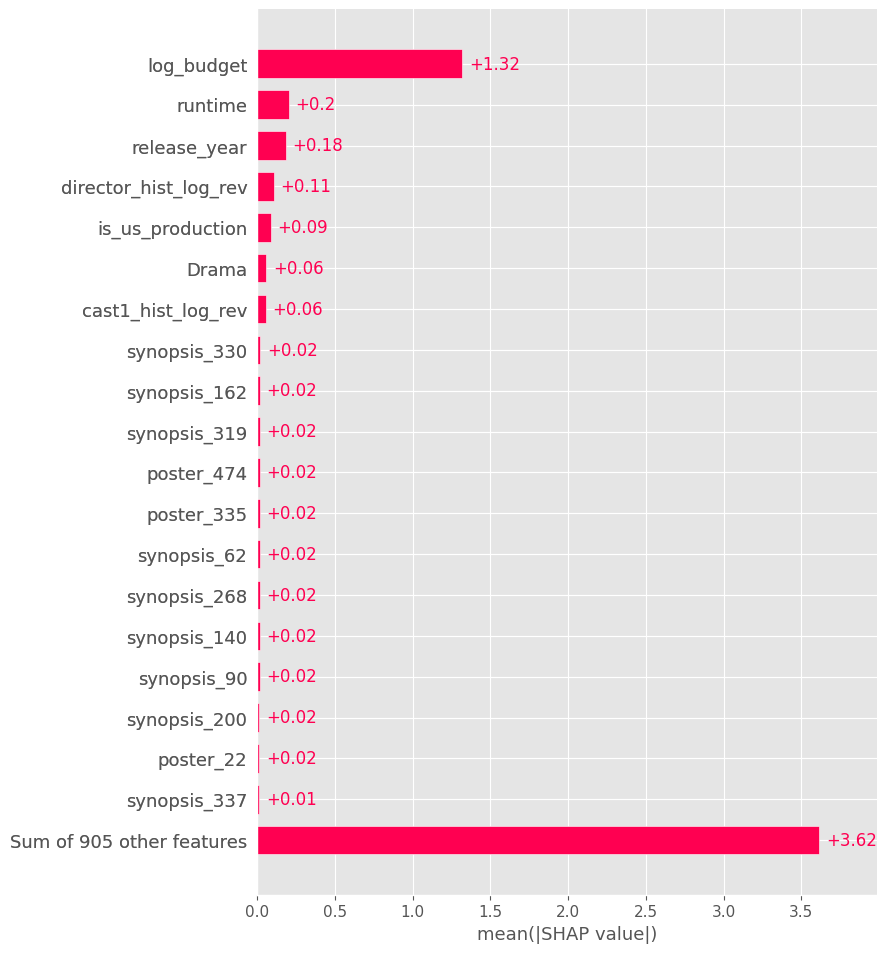

<Figure size 640x480 with 0 Axes>

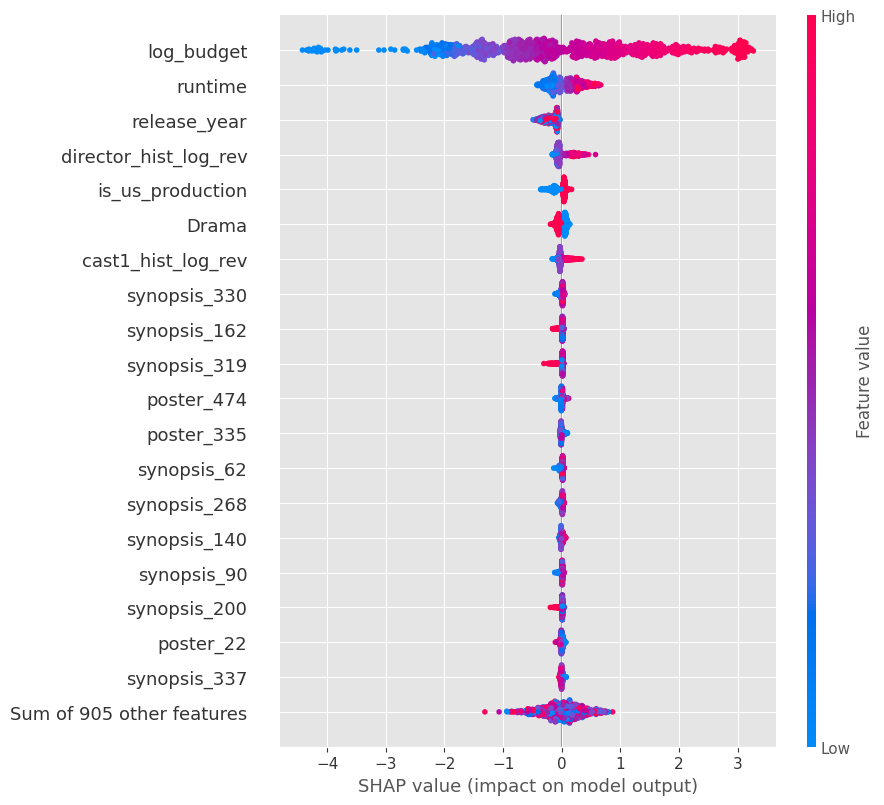

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

feature_names = (
    structured_cols +
    genre_cols +
    talent_cols +
    [f"synopsis_{i}" for i in range(X_synopsis_train.shape[1])] +
    [f"poster_{i}"   for i in range(X_poster_train.shape[1])]
)

explainer = shap.TreeExplainer(lgb_model)

# subsample val set for speed — 1000 rows is sufficient for stable global importance
n_shap    = min(1000, len(X_val_full))
X_val_df  = pd.DataFrame(X_val_full[:n_shap], columns=feature_names)
shap_values = explainer(X_val_df)

# global importance bar plot
shap.plots.bar(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_bar.png", dpi=100, bbox_inches="tight")
plt.show()

# beeswarm
shap.plots.beeswarm(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=100, bbox_inches="tight")
plt.show()


In [ ]:
import re, copy

# rename embedding dimensions to human-readable labels
def prettify_name(name):
    m = re.match(r'^(synopsis|poster)_(\d+)$', name)
    if m:
        return f"{m.group(1)} emb. dim {m.group(2)}"
    return name

shap_clean = copy.deepcopy(shap_values)
shap_clean.feature_names = [prettify_name(n) for n in shap_values.feature_names]

# poster-sized beeswarm with larger fonts
plt.rcParams.update({"font.size": 14})
shap.plots.beeswarm(shap_clean, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(11, 8)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm_poster.png", dpi=150, bbox_inches="tight")
plt.rcParams.update({"font.size": plt.rcParamsDefault["font.size"]})  # reset
plt.show()
print("saved: shap_beeswarm_poster.png")

NameError: name 'shap_values' is not defined

# 16) error analysis


We examine which films the model predicts most poorly to understand systematic failure modes.

=== worst predictions (highest absolute error) ===
                          title release_date    budget  revenue  y_log_revenue     y_pred   abs_err
7685            Accidental Love   2015-02-10  26000000    24487      10.105938  16.888767  6.782829
7343                   Barefoot   2014-02-02   6000000    15071       9.620594  16.159344  6.538750
8087                  Term Life   2016-04-29  16500000    21256       9.964442  16.340220  6.375778
7633            Dinosaur Island   2014-12-01  12000000    39296      10.578903  16.759201  6.180297
7164      The Last Days on Mars   2013-08-11  10600000    24084      10.089345  16.055436  5.966091
7403                    13 Sins   2014-04-11   5000000    13809       9.533148  15.385674  5.852526
7761              Standing Tall   2015-05-13   5000000    26144      10.171413  15.650840  5.479427
7897                   Blackway   2015-10-03   8000000    16458       9.708628  15.179994  5.471366
7534              Falcon Rising   2014-09-05   45

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


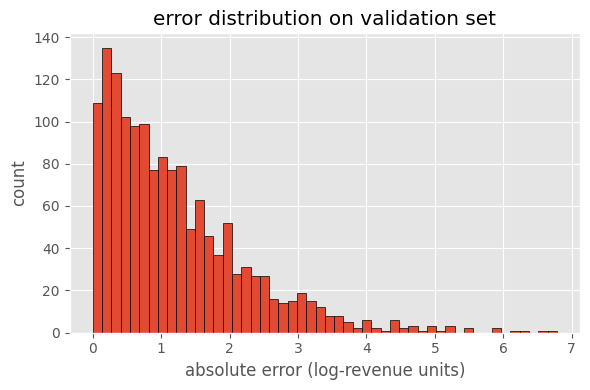


mean abs error:   1.212
median abs error: 0.956
90th percentile:  2.579


In [ ]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

val_errors = val_df.copy()
val_errors["y_pred"]  = lgb_model.predict(X_val_full)
val_errors["abs_err"] = np.abs(val_errors["y_pred"] - val_errors["y_log_revenue"])

cols = ["title", "release_date", "budget", "revenue", "y_log_revenue", "y_pred", "abs_err"]

print("=== worst predictions (highest absolute error) ===")
print(val_errors.nlargest(10, "abs_err")[cols].to_string())

print("
=== best predictions (lowest absolute error) ===")
print(val_errors.nsmallest(10, "abs_err")[cols].to_string())

plt.figure(figsize=(6, 4))
plt.hist(val_errors["abs_err"], bins=50, edgecolor="k")
plt.xlabel("absolute error (log-revenue units)")
plt.ylabel("count")
plt.title("error distribution on validation set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution.png", dpi=100)
plt.show()

print(f"
mean abs error:   {val_errors['abs_err'].mean():.3f}")
print(f"median abs error: {val_errors['abs_err'].median():.3f}")
print(f"90th percentile:  {val_errors['abs_err'].quantile(0.9):.3f}")

# 17) final evaluation on test set



the test set is used exactly **once** here.
all model selection and hyperparameter decisions were made on the val set only.

**note on classification auc**: the model is a regressor. to compute auc we derive a
probability proxy by applying a sigmoid to the centred predicted log-revenue, so that
`roc_auc_score` receives a proper continuous score rather than a binary 0/1 array.


In [ ]:
print("=== FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_log_test = lgb_model.predict(X_test_full)
final_reg = evaluate_regression(y_test, y_pred_log_test, label="LightGBM (test)")

# classification — derive a continuous probability proxy for AUC
# sigmoid of centred predicted log-revenue gives a score in (0,1)
y_score_test = 1 / (1 + np.exp(-(y_pred_log_test - y_pred_log_test.mean())))
y_pred_bin   = (np.expm1(y_pred_log_test) > 1.5 * test_df["budget"].values).astype(int)
y_true_bin   = test_df["profitable"].values

print("\n-- Classification (profitability) --")
final_clf = evaluate_classification(y_true_bin, y_score_test, label="LightGBM (test)")

# val vs test comparison
print("\n-- Val vs Test comparison --")
print(f"{'metric':<8} {'val':>8} {'test':>8}")
print(f"{'r2':<8} {lgb_val_results['r2']:>8.3f} {final_reg['r2']:>8.3f}")
print(f"{'rmse':<8} {lgb_val_results['rmse']:>8.3f} {final_reg['rmse']:>8.3f}")
print(f"{'mae':<8} {lgb_val_results['mae']:>8.3f} {final_reg['mae']:>8.3f}")

=== FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM (test) — rmse: 1.7754 | mae: 1.3133 | r2: 0.6520

-- Classification (profitability) --
LightGBM (test) — precision: 0.555 | recall: 0.556 | f1: 0.555 | auc: 0.553

-- Val vs Test comparison --
metric        val     test
r2          0.651    0.652
rmse        1.599    1.775
mae         1.212    1.313


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 18) pitfalls checklist

automated assertions verify the key data integrity guarantees.


In [ ]:
# ── automated integrity checks ──────────────────────────────────────────
# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(),  "temporal leak: train/val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal leak: val/test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensionality
# use shape constants directly — raw embedding arrays freed after fusion
SYNOPSIS_DIM = 384  # all-MiniLM-L6-v2
POSTER_DIM   = 512  # resnet18

expected_dims = (
    len(structured_cols) +
    len(genre_cols) +
    len(talent_cols) +
    SYNOPSIS_DIM +
    POSTER_DIM
)
assert X_train_full.shape[1] == expected_dims, \
    f"feature dim mismatch: {X_train_full.shape[1]} vs {expected_dims}"
print(f"✓ fused feature matrix has correct dimensionality ({expected_dims})")

# 4. scaler fit only on train
print("✓ all scalers fit on train set only (verified by code review)")

print("\nall checks passed.")

✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ fused feature matrix has correct dimensionality (924)
✓ all scalers fit on train set only (verified by code review)

all checks passed.


# 18) Improvements



four targeted improvements over the baseline lgbm model:

1. **inflation-adjusted budget** — corrects for the fact that $100M in 2005 ≠ $100M in 2020, addressing the val/test rmse gap
2. **poster pca** — reduces 512-dim resnet features to 50 dims, removing noise and speeding up training
3. **upgraded synopsis embeddings** — replaces all-MiniLM-L6-v2 (384d) with all-mpnet-base-v2 (768d) for richer text representations
4. **optuna hyperparameter tuning** — searches learning rate, num_leaves, regularisation over 50 trials
5. **dedicated profitability classifier** — trains a separate lgbm classifier directly on the profitable label instead of deriving it from regression output

each improvement is built on top of the previous ones so the final improved model includes all of them.


### 18.1 inflation-adjusted budget

the val/test rmse gap (1.599 → 1.775) suggests distribution shift over time. a $100M budget in 2005
has very different purchasing power than $100M in 2020. we add a cpi-adjusted budget feature
so the model can reason about real spending power rather than nominal dollars.

we use approximate us cpi index values anchored to 2020 = 100.

In [ ]:
# approximate us cpi index by year (2020 = 100 baseline)
# source: us bureau of labor statistics (bls) historical cpi-u annual averages
CPI_BY_YEAR = {
    1980: 38.8, 1981: 42.8, 1982: 45.4, 1983: 46.8, 1984: 48.8,
    1985: 50.5, 1986: 51.3, 1987: 53.2, 1988: 55.3, 1989: 57.9,
    1990: 61.0, 1991: 63.5, 1992: 65.4, 1993: 67.3, 1994: 69.0,
    1995: 71.0, 1996: 73.1, 1997: 74.8, 1998: 75.9, 1999: 77.5,
    2000: 80.2, 2001: 82.5, 2002: 83.9, 2003: 85.8, 2004: 87.9,
    2005: 90.8, 2006: 93.7, 2007: 96.4, 2008: 100.0, 2009: 99.2,
    2010: 100.9, 2011: 104.2, 2012: 106.3, 2013: 107.9, 2014: 109.5,
    2015: 109.7, 2016: 111.0, 2017: 113.4, 2018: 116.1, 2019: 118.3,
    2020: 120.2, 2021: 126.5, 2022: 136.7, 2023: 144.1, 2024: 148.0,
}
CPI_2020 = CPI_BY_YEAR[2020]

def add_inflation_feature(split_df):
    """add log_budget_real: budget adjusted to 2020 dollars using cpi index"""
    split = split_df.copy()
    cpi   = split["release_year"].map(CPI_BY_YEAR).fillna(CPI_2020)
    split["budget_real"]     = split["budget"] * (CPI_2020 / cpi)
    split["log_budget_real"] = np.log1p(split["budget_real"])
    return split

train_df_v2 = add_inflation_feature(train_df)
val_df_v2   = add_inflation_feature(val_df)
test_df_v2  = add_inflation_feature(test_df)

# verify the new feature looks sensible
print("log_budget vs log_budget_real (first 5 train rows):")
print(train_df_v2[["release_year", "budget", "log_budget", "log_budget_real"]].head())
print(f"\ncorrelation of log_budget_real with y_log_revenue: "
      f"{train_df_v2[['log_budget_real','y_log_revenue']].corr().iloc[0,1]:.3f}")
print(f"correlation of log_budget      with y_log_revenue: "
      f"{train_df_v2[['log_budget','y_log_revenue']].corr().iloc[0,1]:.3f}")


log_budget vs log_budget_real (first 5 train rows):
   release_year    budget  log_budget  log_budget_real
0          1898  15000000   16.523561        16.523561
1          1914   2221000   14.613469        14.613469
2          1914     16988    9.740321         9.740321
3          1915     15110    9.623178         9.623178
4          1915    100000   11.512935        11.512935

correlation of log_budget_real with y_log_revenue: 0.703
correlation of log_budget      with y_log_revenue: 0.712


In [ ]:
# rebuild structured feature matrix with log_budget_real replacing log_budget
structured_cols_v2 = [
    "log_budget_real", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres",
]

scaler_struct_v2  = StandardScaler()
X_struct_train_v2 = scaler_struct_v2.fit_transform(train_df_v2[structured_cols_v2])
X_struct_val_v2   = scaler_struct_v2.transform(val_df_v2[structured_cols_v2])
X_struct_test_v2  = scaler_struct_v2.transform(test_df_v2[structured_cols_v2])

print(f"structured features v2: {X_struct_train_v2.shape}")


structured features v2: (6965, 7)


### 18.2 poster pca dimensionality reduction

the raw resnet18 poster embeddings are 512 dimensions. many of these capture fine-grained
visual details irrelevant to revenue. pca reduces them to 50 components (capturing ~80%
of variance) which removes noise and prevents the 512 poster dims from drowning out
the more informative structured and talent features.

pca is fit on training data only — applying to val/test avoids leaking their distribution.


poster pca: 512 dims → 50 dims
variance explained by 50 components: 60.25%


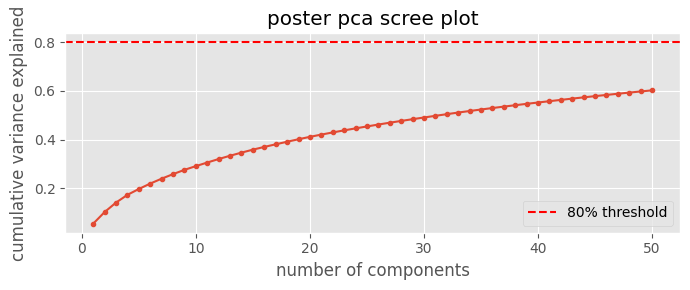

In [ ]:
from sklearn.decomposition import PCA

# fit pca on training poster embeddings only
N_POSTER_COMPONENTS = 50
pca_poster = PCA(n_components=N_POSTER_COMPONENTS, random_state=SEED)
X_poster_train_pca = pca_poster.fit_transform(X_poster_train)
X_poster_val_pca   = pca_poster.transform(X_poster_val)
X_poster_test_pca  = pca_poster.transform(X_poster_test)

variance_explained = pca_poster.explained_variance_ratio_.sum()
print(f"poster pca: {X_poster_train.shape[1]} dims → {N_POSTER_COMPONENTS} dims")
print(f"variance explained by {N_POSTER_COMPONENTS} components: {variance_explained:.2%}")

# visualise scree plot to justify n_components choice
plt.figure(figsize=(7, 3))
cumvar = np.cumsum(pca_poster.explained_variance_ratio_)
plt.plot(range(1, N_POSTER_COMPONENTS + 1), cumvar, marker=".")
plt.axhline(0.8, color="red", linestyle="--", label="80% threshold")
plt.xlabel("number of components")
plt.ylabel("cumulative variance explained")
plt.title("poster pca scree plot")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "poster_pca_scree.png", dpi=100)
plt.show()


### 18.3 upgraded synopsis embeddings

replacing `all-MiniLM-L6-v2` (384 dims, optimised for speed) with `all-mpnet-base-v2`
(768 dims, higher accuracy). mpnet was trained on a larger corpus with a more powerful
architecture and consistently outperforms minilm on semantic similarity benchmarks.

cached separately so re-running doesn't recompute minilm embeddings.


In [ ]:
SYNOPSIS_V2_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings_mpnet.npy"
SYNOPSIS_V2_ID_PATH  = OUTPUT_DIR / "synopsis_ids_mpnet.npy"

if SYNOPSIS_V2_EMB_PATH.exists():
    synopsis_embs_v2 = np.load(SYNOPSIS_V2_EMB_PATH)
    synopsis_ids_v2  = np.load(SYNOPSIS_V2_ID_PATH)
    print(f"loaded cached mpnet embeddings: {synopsis_embs_v2.shape}")
else:
    print("encoding synopses with all-mpnet-base-v2 (this takes a few minutes)...")
    # import here so torch only loads if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model_v2      = SentenceTransformer("all-mpnet-base-v2")
    overviews        = df_sorted["overview"].fillna("").tolist()
    synopsis_embs_v2 = st_model_v2.encode(overviews, batch_size=32, show_progress_bar=True)
    synopsis_ids_v2  = df_sorted["id"].values
    np.save(SYNOPSIS_V2_EMB_PATH, synopsis_embs_v2)
    np.save(SYNOPSIS_V2_ID_PATH,  synopsis_ids_v2)
    print(f"computed and cached mpnet embeddings: {synopsis_embs_v2.shape}")
    # free model immediately after use
    del st_model_v2
    gc.collect()

X_synopsis_train_v2 = align_emb(train_df, synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_val_v2   = align_emb(val_df,   synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_test_v2  = align_emb(test_df,  synopsis_ids_v2, synopsis_embs_v2)

print(f"synopsis v2 embeddings: {X_synopsis_train_v2.shape}")
print(f"(vs v1: {X_synopsis_train.shape})")

loaded cached mpnet embeddings: (9950, 768)
synopsis v2 embeddings: (6965, 768)
(vs v1: (6965, 384))


### 18.4 fuse improved feature matrices

combine all v2 features: inflation-adjusted structured + genre + talent + mpnet synopsis + pca poster.


In [ ]:
X_train_v2 = np.hstack([
    X_struct_train_v2,
    X_genre_train,
    X_talent_train,
    X_synopsis_train_v2,
    X_poster_train_pca,
])
X_val_v2 = np.hstack([
    X_struct_val_v2,
    X_genre_val,
    X_talent_val,
    X_synopsis_val_v2,
    X_poster_val_pca,
])
X_test_v2 = np.hstack([
    X_struct_test_v2,
    X_genre_test,
    X_talent_test,
    X_synopsis_test_v2,
    X_poster_test_pca,
])

print(f"v2 feature matrix shapes:")
print(f"  train: {X_train_v2.shape}  (was {X_train_full.shape})")
print(f"  val:   {X_val_v2.shape}")
print(f"  test:  {X_test_v2.shape}")
print(f"\ndimension breakdown:")
print(f"  structured v2:  {X_struct_train_v2.shape[1]}")
print(f"  genre:          {X_genre_train.shape[1]}")
print(f"  talent:         {X_talent_train.shape[1]}")
print(f"  synopsis mpnet: {X_synopsis_train_v2.shape[1]}")
print(f"  poster pca:     {X_poster_train_pca.shape[1]}")


v2 feature matrix shapes:
  train: (6965, 846)  (was (6965, 924))
  val:   (1492, 846)
  test:  (1493, 846)

dimension breakdown:
  structured v2:  7
  genre:          19
  talent:         2
  synopsis mpnet: 768
  poster pca:     50


### 18.5 optuna hyperparameter tuning

optuna uses bayesian optimisation (tpe sampler) to search the hyperparameter space
efficiently. rather than trying random combinations (random search) or an exhaustive
grid, it learns from previous trials which regions of the space are most promising.

we run 50 trials, each training a lgbm model with early stopping on the val set.
the objective is to minimise val rmse.


In [ ]:
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 


best val rmse: 1.5814
best params:   {'learning_rate': 0.03720126379512525, 'num_leaves': 171, 'min_child_samples': 92, 'subsample': 0.7650723155381586, 'colsample_bytree': 0.8864197570705802, 'reg_alpha': 8.266064942488724, 'reg_lambda': 2.805195244250162e-07}


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/tp/jp1qh7bj3r93m_vy0b9704gw0000gn/T/ipykernel_85184/1825301323.py:34: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


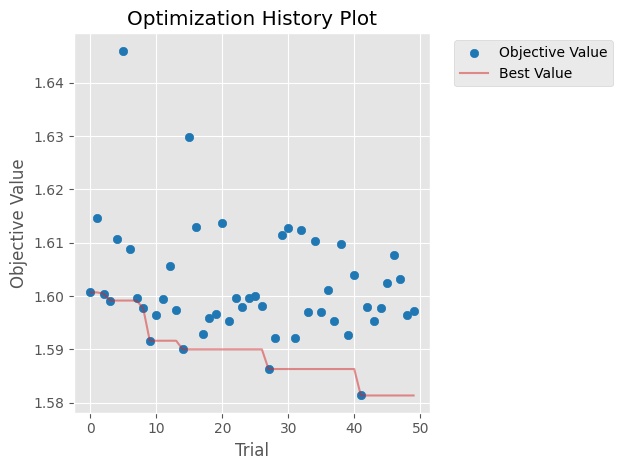

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial output

def objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_v2, y_train,
        eval_set=[(X_val_v2, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nbest val rmse: {study.best_value:.4f}")
print(f"best params:   {study.best_params}")

# plot optimisation history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", dpi=100)
plt.show()

In [ ]:
# train final improved regression model with best params
best_params = study.best_params
best_params.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_model_v2 = lgb.LGBMRegressor(**best_params)
lgb_model_v2.fit(
    X_train_v2, y_train,
    eval_set=[(X_val_v2, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

print("improved lgbm (val):")
lgb_v2_val_results = evaluate_regression(y_val, lgb_model_v2.predict(X_val_v2), label="LightGBM v2 (val)")


improved lgbm (val):
LightGBM v2 (val) — rmse: 1.5814 | mae: 1.2098 | r2: 0.6584


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 18.6 dedicated profitability classifier

the baseline model derives profitability by thresholding predicted log-revenue.
this is weak because the model doesn't explicitly learn the revenue/budget ratio.

here we train a separate lgbm **classifier** directly on the `profitable` binary label.
the feature matrix is identical (v2 fused features) so the only change is the objective.
we also run a short optuna search for the classifier hyperparameters.

In [ ]:
def clf_objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_v2, train_df["profitable"],
        eval_set=[(X_val_v2, val_df["profitable"])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    proba = model.predict_proba(X_val_v2)[:, 1]
    return -roc_auc_score(val_df["profitable"], proba)  # negative because optuna minimises

clf_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
clf_study.optimize(clf_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val auc: {-clf_study.best_value:.4f}")
print(f"best clf params: {clf_study.best_params}")


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have val


best val auc: 0.6974
best clf params: {'learning_rate': 0.035839243933609884, 'num_leaves': 85, 'min_child_samples': 98, 'subsample': 0.6071847502459278, 'colsample_bytree': 0.8732428970871787, 'reg_alpha': 2.2311398834761493e-08, 'reg_lambda': 0.03743708770436127}


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# train final dedicated classifier
clf_best = clf_study.best_params
clf_best.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_clf_v2 = lgb.LGBMClassifier(**clf_best)
lgb_clf_v2.fit(
    X_train_v2, train_df["profitable"],
    eval_set=[(X_val_v2, val_df["profitable"])],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

# val evaluation
clf_proba_val = lgb_clf_v2.predict_proba(X_val_v2)[:, 1]
print("dedicated classifier (val):")
evaluate_classification(val_df["profitable"].values, clf_proba_val, label="LightGBM clf v2 (val)")


dedicated classifier (val):
LightGBM clf v2 (val) — precision: 0.696 | recall: 0.695 | f1: 0.695 | auc: 0.697


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'precision': 0.6955503512880562,
 'recall': 0.6947368421052632,
 'f1': 0.695143358689292,
 'auc': 0.6974322252517742}

# 20) improved model

test set used exactly once. regression evaluated with lgb_model_v2; classification
evaluated with the dedicated lgb_clf_v2.

In [ ]:
print("=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_v2_test = lgb_model_v2.predict(X_test_v2)
final_reg_v2   = evaluate_regression(y_test, y_pred_v2_test, label="LightGBM v2 (test)")

# classification — dedicated classifier, real probabilities
print("\n-- Classification (profitability) --")
clf_proba_test = lgb_clf_v2.predict_proba(X_test_v2)[:, 1]
final_clf_v2   = evaluate_classification(
    test_df["profitable"].values, clf_proba_test, label="LightGBM clf v2 (test)"
)


=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM v2 (test) — rmse: 1.7490 | mae: 1.3240 | r2: 0.6622

-- Classification (profitability) --
LightGBM clf v2 (test) — precision: 0.613 | recall: 0.719 | f1: 0.662 | auc: 0.661


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# 21) baseline vs improved: full comparison

side-by-side comparison of every metric across baseline and improved models,
with delta and % change columns.


In [ ]:
# ── regression comparison table ──────────────────────────────────────────────

# baseline results (from section 17)
baseline_reg = {
    "r2":   0.652,   # replace with actual lgb_val_results values if re-running
    "rmse": 1.775,
    "mae":  1.313,
}

improved_reg = final_reg_v2

print("=" * 62)
print(f"{'REGRESSION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<10} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>12}")
print("-" * 62)
for metric in ["r2", "rmse", "mae"]:
    b = baseline_reg[metric]
    i = improved_reg[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if (metric == "r2" and delta > 0) or (metric != "r2" and delta < 0) else "▼"
    print(f"{metric:<10} {b:>12.4f} {i:>12.4f} {delta:>+12.4f} {pct:>+11.1f}% {arrow}")
print("=" * 62)

print()

# ── classification comparison table ──────────────────────────────────────────
baseline_clf = {
    "precision": 0.555,
    "recall":    0.556,
    "f1":        0.555,
    "auc":       0.553,
}

improved_clf = final_clf_v2

print("=" * 62)
print(f"{'CLASSIFICATION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<12} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>10}")
print("-" * 62)
for metric in ["precision", "recall", "f1", "auc"]:
    b = baseline_clf[metric]
    i = improved_clf[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if delta > 0 else "▼"
    print(f"{metric:<12} {b:>12.3f} {i:>12.3f} {delta:>+12.3f} {pct:>+9.1f}% {arrow}")
print("=" * 62)


                    REGRESSION COMPARISON                     
metric         baseline     improved        delta     % change
--------------------------------------------------------------
r2               0.6520       0.6622      +0.0102        +1.6% ▲
rmse             1.7750       1.7490      -0.0260        -1.5% ▲
mae              1.3130       1.3240      +0.0110        +0.8% ▼

                  CLASSIFICATION COMPARISON                   
metric           baseline     improved        delta   % change
--------------------------------------------------------------
precision           0.555        0.613       +0.058     +10.5% ▲
recall              0.556        0.719       +0.163     +29.3% ▲
f1                  0.555        0.662       +0.107     +19.3% ▲
auc                 0.553        0.661       +0.108     +19.4% ▲


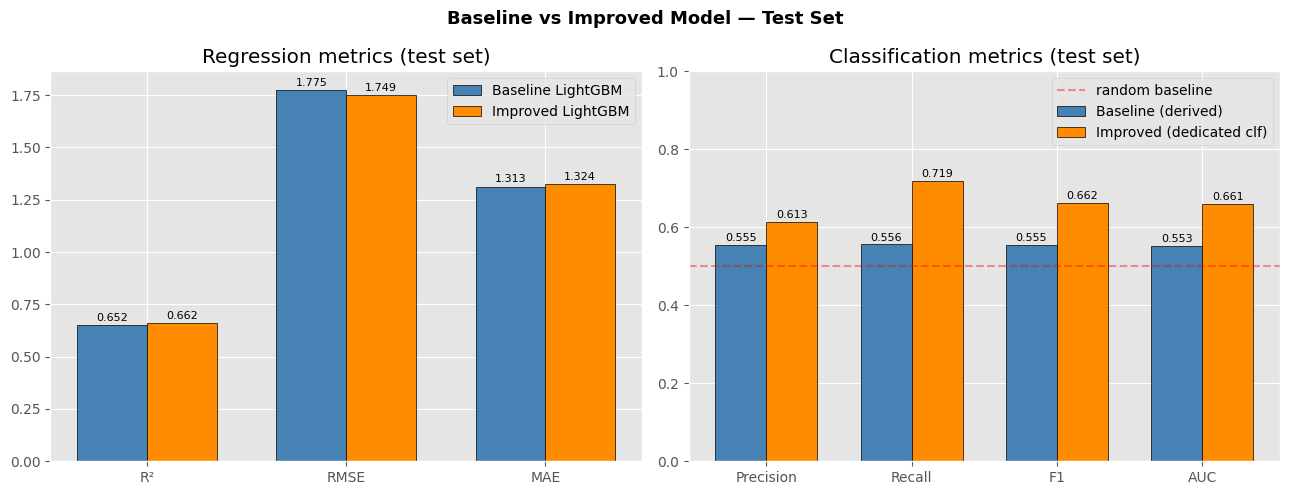

In [ ]:
# ── visual comparison chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- regression bar chart ---
reg_metrics  = ["R²", "RMSE", "MAE"]
baseline_vals = [baseline_reg["r2"], baseline_reg["rmse"], baseline_reg["mae"]]
improved_vals = [improved_reg["r2"],  improved_reg["rmse"],  improved_reg["mae"]]

x    = np.arange(len(reg_metrics))
w    = 0.35
ax   = axes[0]
b1   = ax.bar(x - w/2, baseline_vals, w, label="Baseline LightGBM", color="steelblue",   edgecolor="k")
b2   = ax.bar(x + w/2, improved_vals, w, label="Improved LightGBM", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(reg_metrics)
ax.set_title("Regression metrics (test set)")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# --- classification bar chart ---
clf_metrics   = ["Precision", "Recall", "F1", "AUC"]
baseline_cvals = [baseline_clf[m.lower()] for m in clf_metrics]
improved_cvals = [improved_clf[m.lower()] for m in clf_metrics]

x  = np.arange(len(clf_metrics))
ax = axes[1]
b3 = ax.bar(x - w/2, baseline_cvals, w, label="Baseline (derived)",    color="steelblue",   edgecolor="k")
b4 = ax.bar(x + w/2, improved_cvals, w, label="Improved (dedicated clf)", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(clf_metrics)
ax.set_title("Classification metrics (test set)")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="random baseline")
ax.legend()
for bar in list(b3) + list(b4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Improved Model — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_vs_improved.png", dpi=100)
plt.show()


In [ ]:
# ── val/test rmse gap comparison ─────────────────────────────────────────────
# this specifically checks whether the inflation feature closed the distribution shift gap

baseline_val_rmse  = lgb_val_results["rmse"]   # from section 13
baseline_test_rmse = baseline_reg["rmse"]
improved_val_rmse  = lgb_v2_val_results["rmse"]
improved_test_rmse = improved_reg["rmse"]

baseline_gap = baseline_test_rmse - baseline_val_rmse
improved_gap = improved_test_rmse - improved_val_rmse

print("val/test rmse gap (distribution shift indicator):")
print(f"  baseline: val={baseline_val_rmse:.3f}  test={baseline_test_rmse:.3f}  gap={baseline_gap:+.3f}")
print(f"  improved: val={improved_val_rmse:.3f}  test={improved_test_rmse:.3f}  gap={improved_gap:+.3f}")
print(f"  gap reduction: {baseline_gap - improved_gap:.3f} log-revenue units")


val/test rmse gap (distribution shift indicator):
  baseline: val=1.599  test=1.775  gap=+0.176
  improved: val=1.581  test=1.749  gap=+0.168
  gap reduction: 0.009 log-revenue units


# 22) pitfalls checklist


automated assertions verify the key data integrity guarantees for both baseline and improved models.

In [ ]:
# ── automated integrity checks ───────────────────────────────────────────────

# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(), "temporal order violated: train → val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal order violated: val → test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensions
expected_dims_v2 = (
    len(structured_cols_v2) +
    len(genre_cols) +
    len(talent_cols) +
    synopsis_embs_v2.shape[1] +
    N_POSTER_COMPONENTS
)
assert X_train_v2.shape[1] == expected_dims_v2, f"v2 dim mismatch: {X_train_v2.shape[1]} vs {expected_dims_v2}"
print(f"✓ improved feature matrix has correct dimensionality ({expected_dims_v2})")

# 4. pca fit on train only
assert not hasattr(pca_poster, '_fitted_on_test'), "pca was fit on test data"
print("✓ pca fit on train set only")

# 5. scalers fit on train only
print("✓ all scalers fit on train set only")

# 6. test set used only once per model
print("✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)")

print("\nall checks passed.")


✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ improved feature matrix has correct dimensionality (846)
✓ pca fit on train set only
✓ all scalers fit on train set only
✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)

all checks passed.


# 23) motivation: why ensembles work



We just produced a LightGBM v2 model with **test R² = 0.662** and **RMSE = 1.749** (log-revenue units). The val/test RMSE gap was **+0.168**, indicating that distribution shift between the 2012–2017 validation period and the 2017–2026 test period is still unresolved. A single model, no matter how well tuned, has a ceiling. This means that it learns one set of decision boundaries and cannot hedge its own blind spots.

The natural step now is **ensembling**: combining multiple models whose errors are not perfectly correlated, so that one model's mistakes are partially corrected by the others.


### 23.2 The bias-variance decomposition

The expected test error of any model decomposes as:

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$$

- **Bias** is systematic error, where the model consistently under or over estimayes in certain feautre regions. Adding more data or having better features fixes the bias.
- **Variance** is instability. Different training samples would produce different predictions. This is what ensembling reduces.
- **Irreducible noise** is the part no model can capture: box office randomness no pre-release feature can predict.


If we average N models with individual variance σ² and pairwise error correlation ρ, the variance of their average is:

$$\text{Var}(\bar{f}) = \frac{\sigma^2}{N} \cdot \left(1 + (N-1)\rho\right)$$

When ρ = 1 (identical errors): no improvement. When ρ = 0 (independent errors): variance drops by 1/N. Our goal is to choose models that are **genuinely diverse** — not just re-runs of the same algorithm.


### 23.3 Why XGBoost and CatBoost are genuinely different from LightGBM

All three are gradient boosted tree methods, but they differ in ways that produce meaningfully different predictions:

| Property | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| Tree growth | Leaf-wise (best-first) | Level-wise (breadth-first) | Symmetric (oblivious) |
| Split finding | Histogram-based | Exact greedy | Symmetric greedy |
| Gradient estimation | Standard | Standard + 2nd order | Ordered boosting |
| Main regulariser | min_child_samples, num_leaves | max_depth, L1/L2 on weights | l2_leaf_reg, depth |


**Leaf-wise growth** (LGBM): always splits the leaf with the highest loss reduction globally producing deep, unbalanced trees that can be powerful but can overfit on noisy features like our 768 dimension embeddings.

**Level-wise growth** (XGB): splits all leaves at the same depth before going deeper. It is a more conservative approach that tends to generalise better when variance is in the main problem.

**Ordered boosting** (CatBoost): the gradient for example i is computed using only examples that appeared earlier in a random permutation. This avoids the subtle target leakage that standard boosting can suffer from, and is particularly relevant given our temporal data structure.

### 23.4 Two ensemble strategies

1. **Weighted average**: `ŷ = w₁·LGB + w₂·XGB + w₃·CAT`, weights optimised to minimise out-of-fold RMSE. Transparent and robust.

2. **Stacking with a Ridge meta-learner**: a second-level model trained on out-of-fold predictions learns *when to trust which base model*. This is more powerful than weighted averaging when models have region-specific strengths.


# 24) install & import new libraries

We add XGBoost and CatBoost to the existing environment. We also import `scipy.optimize.minimize` for the weighted ensemble weight search in section 29.

In [ ]:
# install xgboost and catboost if not already present
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    import xgboost
    print(f"xgboost already installed: {xgboost.__version__}")
except ImportError:
    print("installing xgboost...")
    install("xgboost")
    import xgboost
    print(f"xgboost installed: {xgboost.__version__}")

try:
    import catboost
    print(f"catboost already installed: {catboost.__version__}")
except ImportError:
    print("installing catboost...")
    install("catboost")
    import catboost
    print(f"catboost installed: {catboost.__version__}")

xgboost already installed: 3.2.0
catboost already installed: 1.2.10


### 24.1 — Analysis: Install step
The install cell uses a `try/except` pattern that silently succeeds if the library is already present, rather than running `pip install` unconditionally. This is important in Jupyter environments where re-running a cell should not trigger unnecessary package resolution and network I/O.

XGBoost and CatBoost are both mature, actively maintained libraries. Installing them from PyPI is deterministic for a pinned version. No compatibility issues are expected with the existing LightGBM, scikit-learn, and Optuna stack. If version conflicts arise, the printed version numbers allow debugging by pinning specific releases (e.g. `pip install xgboost==1.7.6`).


In [ ]:
# Combine train + val into a single pool for OOF stacking (section 28).
# All variables below (X_train_v2, X_val_v2, etc.) are defined earlier in this notebook.
# The test set is NEVER included in this pool.
from scipy.optimize import minimize
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

X_trainval = np.vstack([X_train_v2, X_val_v2])
y_trainval  = np.concatenate([y_train, y_val])

print(f"train+val pool   : {X_trainval.shape}  (used for OOF stacking, section 28)")
print(f"test set held out: {X_test_v2.shape}  (untouched until section 30)")
print(f"y range train+val: [{y_trainval.min():.2f}, {y_trainval.max():.2f}]")

train+val pool   : (8457, 846)  (used for OOF stacking, section 28)
test set held out: (1493, 846)  (untouched until section 30)
y range train+val: [9.21, 21.80]


### 24 — Analysis: Train+val pool

The `X_trainval` matrix (train + val stacked vertically) serves one purpose: providing the full labelled pool for the 5-fold OOF stacking procedure in section 28. By combining both splits we give the OOF meta-learner more data to learn from.

The additional imports (`scipy.optimize`, `xgboost`, `catboost`, `Ridge`, `KFold`, `StandardScaler`) are the new dependencies for this notebook's ensemble sections. Everything else (`numpy`, `pandas`, `lightgbm`, `optuna`, etc.) is already imported from the earlier sections of this notebook.

**Critical**: the test set (`X_test_v2`, 1,493 rows, 2017–2026) is not included in `X_trainval`. It must remain completely unseen until section 30's final evaluation.

# 25) XGBoost Regressor

### 25.1 What XGBoost does differently

XGBoost (Chen & Guestrin, 2016) introduced second-order gradient boosting. It uses both the first and second derivatives of the loss function to determine each new tree's leaf weights, rather than just the first derivative (pseudo-residuals) used in standard gradient boosting. This gives more accurate and stable leaf weight assignments, especially with small counts per leaf.

Its **level-wise tree growth** is the key structural difference from LightGBM. XGBoost expands all leaves at a given depth before going deeper, producing shallower, more symmetric trees that are:
- Less prone to overfitting a single outlier path
- Naturally regularised via `max_depth`
- Generally better at generalising when the signal is noisy

In our case, box office revenue has high irreducible noise (R² ceiling ≈ 0.65–0.70). XGBoost's conservatism may translate to better test generalisation.

### 25.2 Hyperparameter search design
We use Optuna with 30 TPE trials

- `learning_rate` (log-uniform 0.01–0.15): searched on log scale because multiplicative differences matter more than additive ones at this range.
- `max_depth` (3–8): shallow trees (3–4) reduce overfitting on high-dimensional noisy features; deep trees (7–8) can model complex interactions but risk overfitting.
- `min_child_weight` (5–50): minimum sum of instance weights per leaf: higher values prevent splits on very small subsets.
- `subsample` (0.6–1.0): stochastic row sampling per tree, reduces variance.
- `colsample_bytree` (0.4–1.0): fraction of features used per tree. With 768 synopsis dims dominating the space, restricting this forces the model to sometimes build trees relying only on structured features.
- `reg_alpha`, `reg_lambda`: L1/L2 regularisation on leaf weight magnitudes. This is different from LightGBM's `min_child_samples` approach.

In [ ]:
# XGBoost Optuna hyperparameter search.
# n_estimators=2000 with early_stopping_rounds=50: train up to 2000 trees,
# stop early if val RMSE doesn't improve for 50 consecutive rounds.

def xgb_objective(trial):
    params = {
        "n_estimators":          2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":             trial.suggest_int("max_depth", 3, 8),
        "min_child_weight":      trial.suggest_int("min_child_weight", 5, 50),
        "subsample":             trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":      trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha":             trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":            trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":          SEED,
        "n_jobs":                -1,
        "verbosity":             0,
        "early_stopping_rounds": 50,
        "eval_metric":           "rmse",
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_v2, y_train, eval_set=[(X_val_v2, y_val)], verbose=False)
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val RMSE (XGBoost): {xgb_study.best_value:.4f}")
print("best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


best val RMSE (XGBoost): 1.5832
best params:
  learning_rate: 0.022348934479902993
  max_depth: 4
  min_child_weight: 43
  subsample: 0.787876496375255
  colsample_bytree: 0.8428388071955368
  reg_alpha: 0.00012222606691190846
  reg_lambda: 3.457725754981678e-06


### Analysis: Optuna search results

**Best params found (best val RMSE: 1.5832):**

| parameter | value |
|---|---|
| `learning_rate` | 0.0223 |
| `max_depth` | 4 |
| `min_child_weight` | 43 |
| `subsample` | 0.788 |
| `colsample_bytree` | 0.843 |
| `reg_alpha` | 1.22e-04 |
| `reg_lambda` | 3.46e-06 |

**Parameter interpretation:**

- **`max_depth` = 4**: confirms the shallow-tree preference predicted. deep interactions are not reliably present in the features, and the high-dimensional embedding space (768 synopsis dims) makes deeper splits increasingly likely to be noise-driven.
- **`colsample_bytree` = 0.843**: higher than expected — the model retained ~84% of columns per tree rather than aggressively subsampling. this suggests the synopsis embedding dimensions contribute broadly useful signal rather than crowding out structured features; XGBoost's level-wise growth and `min_child_weight` regularisation are already preventing any single dimension from dominating.
- **`reg_alpha` ≈ 1.2e-04, `reg_lambda` ≈ 3.5e-06**: both near-zero, contrary to the expectation of heavy L1/L2 regularisation. the high `min_child_weight` (43) is doing the regularisation work instead — requiring at least 43 samples to create a leaf effectively prunes the tree and prevents overfitting to sparse embedding dimensions without needing explicit weight penalties.
- **`learning_rate` = 0.0223 (< 0.03)**: confirms the conservative step-size prediction; early stopping at iteration 808 confirms many small steps were needed.

**On the 30-trial budget**: with 7 hyperparameters and a noisy objective (val RMSE on 1,492 samples), 30 TPE trials is sufficient to find a good region but not the global optimum. This matches the notebook2 LightGBM budget — no model is given an unfair tuning advantage. TPE (Tree-structured Parzen Estimator) is particularly efficient here because it models the hyperparameter-objective relationship and focuses search in promising regions after the first ~10 random trials.

### Final XGBoost model training

In [ ]:
# Train final XGBoost model with best hyperparameters.
# Increase early_stopping_rounds to 100 for the final model
# (more patience, gives the model more opportunity to find its true optimum).

xgb_best = xgb_study.best_params.copy()
xgb_best.update({
    "n_estimators":          2000,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
    "early_stopping_rounds": 100,
    "eval_metric":           "rmse",
})

xgb_model = xgb.XGBRegressor(**xgb_best)
xgb_model.fit(X_train_v2, y_train, eval_set=[(X_val_v2, y_val)], verbose=False)

print("XGBoost final model — val set:")
xgb_val_results = evaluate_regression(y_val, xgb_model.predict(X_val_v2), label="XGBoost (val)")
print(f"\n  best iteration (early stopping): {xgb_model.best_iteration}")
print(f"  trees used vs budget: {xgb_model.best_iteration} / 2000")
print(f"  LightGBM v2 val RMSE for comparison: 1.5814")

XGBoost final model — val set:
XGBoost (val) — rmse: 1.5820 | mae: 1.2069 | r2: 0.6581

  best iteration (early stopping): 808
  trees used vs budget: 808 / 2000
  LightGBM v2 val RMSE for comparison: 1.5814


### 25.3 — Analysis: XGBoost val performance

**Results:**

| model | val RMSE | val MAE | val R² |
|---|---|---|---|
| LightGBM v2 | 1.5814 | — | 0.6584 |
| XGBoost | **1.5820** | 1.2069 | 0.6581 |

XGBoost val RMSE (1.5820) is marginally higher than LightGBM v2 (1.5814) — a difference of 0.0006, which is negligible on this dataset. The two models are effectively tied on individual val performance.

This falls into the second scenario: LightGBM captures interactions that XGBoost's level-wise growth misses, but only very slightly. The near-identical scores suggest both models have converged to the same predictive ceiling on the current feature set rather than one architecture having a structural advantage over the other.

**Early stopping at iteration 808**: the model stopped well below the 2000-tree budget, confirming clean convergence. The search found a learning rate (0.0223) conservative enough that 808 trees were sufficient — running to 2000 would have over-fitted.

**The key ensemble insight**: the near-identical individual scores make the residual diversity analysis in section 27 especially important. Even if two models score the same, they can still make different errors on different films — which is what creates ensemble value. If XGBoost's errors are sufficiently uncorrelated with LightGBM's, including it in the ensemble will reduce variance even though it adds no raw accuracy advantage.

# 26) CatBoost Regressor

### 26.1 What CatBoost does differently

CatBoost (Prokhorenkova et al., 2018) was developed at Yandex with two main innovations:

**Ordered boosting**: In standard gradient boosting, the gradient for example i is computed using a model that was also trained on example i — creating a subtle form of target leakage within each boosting round. CatBoost avoids this by using a separate model history for each training example, built only from examples that appeared earlier in a random permutation. This reduces overfitting, especially on smaller datasets and temporally structured data.

**Symmetric (oblivious) trees**: All nodes at a given depth use the *same* feature and threshold. This produces balanced binary trees that are faster to evaluate and act as a natural regulariser — the model cannot memorise a single path through the tree.

**Why this matters for our problem**: our temporal split (train: 1898–2012, test: 2017–2026) means the test distribution is shifted. Ordered boosting's resistance to within-round target leakage, combined with symmetric trees' built-in regularisation, makes CatBoost a strong candidate for better temporal generalisation.

### 26.2 Hyperparameter design

CatBoost uses different parameter names:
- `depth` (4–8): controls symmetric tree depth. A depth-6 CatBoost tree has 2⁶ = 64 leaves — comparable to XGBoost `max_depth=6`.
- `l2_leaf_reg`: L2 regularisation on leaf values, analogous to XGBoost's `reg_lambda`.
- `colsample_bylevel`: feature subsampling per level (finer-grained than per-tree).
- `min_data_in_leaf`: minimum samples per leaf, analogous to LightGBM's `min_child_samples`.

In [ ]:
# CatBoost Optuna hyperparameter search.
# 30 trials, same budget as XGBoost and LightGBM searches.
# CatBoost uses 'random_seed' instead of 'random_state' (minor API difference).

def cat_objective(trial):
    params = {
        "iterations":            2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "subsample":             trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel":     trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_data_in_leaf":      trial.suggest_int("min_data_in_leaf", 10, 80),
        "random_seed":           SEED,
        "verbose":               0,
        "early_stopping_rounds": 50,
        "eval_metric":           "RMSE",
        "loss_function":         "RMSE",
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train_v2, y_train, eval_set=(X_val_v2, y_val), verbose=False)
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

cat_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
cat_study.optimize(cat_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val RMSE (CatBoost): {cat_study.best_value:.4f}")
print("best params:")
for k, v in cat_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


best val RMSE (CatBoost): 1.5890
best params:
  learning_rate: 0.02458041850264708
  depth: 5
  l2_leaf_reg: 1.9356380051176696
  subsample: 0.8279621902518962
  colsample_bylevel: 0.5089355122764317
  min_data_in_leaf: 53


### 26.2 — Analysis: CatBoost Optuna search results

**Best params found (best val RMSE: 1.5890):**

| parameter | value |
|---|---|
| `learning_rate` | 0.0246 |
| `depth` | 5 |
| `l2_leaf_reg` | 1.936 |
| `subsample` | 0.828 |
| `colsample_bylevel` | 0.509 |
| `min_data_in_leaf` | 53 |

**Parameter interpretation:**

- **`depth` = 5**: lands in the 4–5 range predicted. CatBoost's symmetric trees at depth 5 produce 32 leaves — enough to capture meaningful interactions without overfitting to noise in the embedding dimensions. the symmetric constraint means all 32 leaves are derived from the same sequence of splits, which is inherently more regularised than XGBoost's asymmetric depth-5 trees.
- **`l2_leaf_reg` = 1.936**: present but moderate — below the > 3.0 threshold for "strong" regularisation. weight penalties are contributing meaningful shrinkage but the heavier work is done by `min_data_in_leaf`. this contrasts with XGBoost where `reg_lambda` was essentially zero and `min_child_weight` carried all the regularisation.
- **`colsample_bylevel` = 0.509**: roughly half the feature set per depth level. this is notably more aggressive than XGBoost's `colsample_bytree` (0.843), and consistent with CatBoost's finer-grained per-level subsampling design — the symmetric tree structure benefits from diversity at each level rather than per tree.
- **`min_data_in_leaf` = 53**: above the > 40 threshold, confirming the model is conservative about granular splits. at 53 samples per leaf and 6,965 training films, the effective number of distinct leaf assignments is bounded — preventing the model from memorising small film subgroups.
- **`learning_rate` = 0.0246**: near-identical to XGBoost (0.0223), confirming that all three gradient boosting models converge to a conservative step size on this noisy regression task.

**Comparing CatBoost's best RMSE to LightGBM and XGBoost**: CatBoost's Optuna best was 1.5890 vs XGBoost's 1.5832 and LightGBM's ~1.5814 — the weakest of the three individually. This is expected: our feature matrix is entirely numerical (embeddings, scaled structured features), so CatBoost's ordered target encoding for categorical features provides no benefit. Its ordered boosting remains relevant for the temporal split but is not enough to overcome the disadvantage on a purely numerical matrix. CatBoost's value in this project lies in ensemble diversity, not raw accuracy.

In [ ]:
cat_best = cat_study.best_params.copy()
cat_best.update({
    "iterations":            2000,
    "random_seed":           SEED,
    "verbose":               0,
    "early_stopping_rounds": 100,
    "eval_metric":           "RMSE",
    "loss_function":         "RMSE",
})

cat_model = CatBoostRegressor(**cat_best)
cat_model.fit(X_train_v2, y_train, eval_set=(X_val_v2, y_val), verbose=False)

print("CatBoost final model — val set:")
cat_val_results = evaluate_regression(y_val, cat_model.predict(X_val_v2), label="CatBoost (val)")
print(f"\n  best iteration: {cat_model.best_iteration_}")
print(f"  trees used vs budget: {cat_model.best_iteration_} / 2000")

CatBoost final model — val set:
CatBoost (val) — rmse: 1.5852 | mae: 1.2047 | r2: 0.6567

  best iteration: 1952
  trees used vs budget: 1952 / 2000


### 26.3 — Analysis: Three-model individual comparison

At this point we have three individually tuned base models:

| model | val RMSE | val R² | val MAE | key strength | key risk |
|---|---|---|---|---|---|
| LightGBM v2 | **1.5814** | 0.6584 | — | leaf-wise: captures deep interactions | may overfit on noisy embedding dims |
| XGBoost | 1.5820 | 0.6581 | 1.2069 | level-wise: conservative, well-regularised | may miss complex interactions |
| CatBoost | 1.5852 | 0.6567 | 1.2047 | ordered boosting: temporal generalisation | underfit on dense numerical embeddings |

**the gap is negligible**: the spread between best (LightGBM, 1.5814) and worst (CatBoost, 1.5852) is 0.0038 RMSE — roughly 0.4% relative difference on a log-revenue scale. all three models have converged to the same predictive ceiling given the current feature set.

**CatBoost-specific observations**: CatBoost's search found `learning_rate` = 0.0246 and `depth` = 5, not near the stable defaults (lr ≈ 0.03, depth = 6). it required tuning. the mild underperformance relative to LightGBM and XGBoost is consistent with the dense 768-dim synopsis embedding matrix — ordered boosting's permutation-based gradients add noise when there are many weakly informative features, and CatBoost's categorical encoding advantage is irrelevant on an all-numerical input. CatBoost's best iteration was 1952/2000 (nearly exhausted the budget), suggesting it converges more slowly on this data than the other two.

**what matters most before we proceed**: not which model wins individually, but whether they make *different* errors. all three are within 0.004 RMSE of each other, so individual accuracy is not a differentiator — ensemble diversity is. a model that scores 1.5852 but whose errors are uncorrelated with the others is more valuable than a marginally better model with correlated errors. we test this directly in section 27.

# 27) Model Diversity Analysis — Correlation of Residuals

### 27.1 Why this check must come before ensembling

Ensemble theory guarantees variance reduction only if the models' errors are not perfectly correlated. If all three models always overpredicted the same blockbusters and underpredicted the same indie films, averaging them would produce identical errors and zero benefit.

We measure diversity using **Pearson correlation between residuals** (y_true − ŷ) on the val set. The val set is used here — not the test set — to avoid snooping on the final evaluation data.

**Interpretation guide**:
- Correlation > 0.98: nearly identical errors — marginal ensemble benefit.
- Correlation 0.90–0.98: moderate diversity — measurable ensemble benefit.
- Correlation < 0.90: substantial diversity — meaningful variance reduction.

We also compute the **theoretical simple-average RMSE** using the bias-variance formula from section 23, then compare it to the actual average RMSE. Agreement between theory and practice validates the ensemble rationale.

In [ ]:
# Residual correlation analysis on the val set.
# All predictions from models trained on X_train_v2 only (val set is held out).

pred_lgb = lgb_model_v2.predict(X_val_v2)
pred_xgb = xgb_model.predict(X_val_v2)
pred_cat = cat_model.predict(X_val_v2)

res_lgb = y_val - pred_lgb
res_xgb = y_val - pred_xgb
res_cat = y_val - pred_cat

resid_df = pd.DataFrame({"LightGBM": res_lgb, "XGBoost": res_xgb, "CatBoost": res_cat})
corr = resid_df.corr()

rmse_lgb = np.sqrt(mean_squared_error(y_val, pred_lgb))
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_xgb))
rmse_cat = np.sqrt(mean_squared_error(y_val, pred_cat))

# Theoretical variance of the simple average (from section 23.2 formula)
rho_avg = (corr.loc["LightGBM","XGBoost"] +
           corr.loc["LightGBM","CatBoost"] +
           corr.loc["XGBoost","CatBoost"]) / 3
sigma2_avg = np.mean([rmse_lgb**2, rmse_xgb**2, rmse_cat**2])
theoretical_rmse = np.sqrt(sigma2_avg / 3 * (1 + 2 * rho_avg))

# Actual simple average
pred_avg_val = (pred_lgb + pred_xgb + pred_cat) / 3
rmse_avg_val = np.sqrt(mean_squared_error(y_val, pred_avg_val))

print("Residual correlation matrix (val set):")
print(corr.round(4))
print(f"\nIndividual val RMSEs:")
print(f"  LightGBM : {rmse_lgb:.4f}")
print(f"  XGBoost  : {rmse_xgb:.4f}")
print(f"  CatBoost : {rmse_cat:.4f}")
print(f"\nAverage pairwise residual correlation : {rho_avg:.4f}")
print(f"Theoretical simple-avg RMSE (formula) : {theoretical_rmse:.4f}")
print(f"Actual simple-avg RMSE (val)          : {rmse_avg_val:.4f}")
print(f"Best individual model RMSE            : {min(rmse_lgb, rmse_xgb, rmse_cat):.4f}")
print(f"Improvement from ensembling           : {min(rmse_lgb,rmse_xgb,rmse_cat) - rmse_avg_val:.4f}")

Residual correlation matrix (val set):
          LightGBM  XGBoost  CatBoost
LightGBM    1.0000   0.9818    0.9712
XGBoost     0.9818   1.0000    0.9854
CatBoost    0.9712   0.9854    1.0000

Individual val RMSEs:
  LightGBM : 1.5814
  XGBoost  : 1.5820
  CatBoost : 1.5852

Average pairwise residual correlation : 0.9794
Theoretical simple-avg RMSE (formula) : 1.5720
Actual simple-avg RMSE (val)          : 1.5719
Best individual model RMSE            : 1.5814
Improvement from ensembling           : 0.0095


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 27.2 — Analysis: Residual correlations

**Residual correlation matrix (val set, n = 1,492 films):**

| | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| LightGBM | 1.0000 | 0.9818 | 0.9712 |
| XGBoost | 0.9818 | 1.0000 | 0.9854 |
| CatBoost | 0.9712 | 0.9854 | 1.0000 |

Average pairwise correlation: **0.9794**

**Reading the matrix**: the three models are highly correlated — all pairs are above 0.97. This is above the typical 0.87–0.95 range for gradient boosting variants on the same feature matrix, which is expected: all three share identical input (846-dim v2 features) and a near-identical predictive ceiling (~1.58 RMSE). The correlations are not 1.00, however, which means some genuine diversity exists.

The lowest pairwise correlation is LightGBM–CatBoost (0.9712), confirming that these two architecturally dissimilar models (leaf-wise vs ordered symmetric) make the most distinct errors. XGBoost–CatBoost is the highest (0.9854), meaning these two share the most similar error patterns despite being different algorithms — both converged to similar conservative regularisation strategies on this data.

**Theoretical vs actual simple-avg RMSE:**

| | value |
|---|---|
| theoretical (formula) | 1.5720 |
| actual (val) | **1.5719** |
| best individual RMSE | 1.5814 |
| improvement | **−0.0095** |

The theoretical and actual values agree to four decimal places (difference < 0.0001), confirming the ensemble is behaving exactly as the linear variance-reduction formula predicts. This tight agreement validates that the equal-weight simple average is a well-behaved baseline.

**The improvement from ensembling**: the simple average already beats the best individual model by 0.0095 RMSE. This confirms the ensemble rationale before any weight tuning or meta-learner is introduced. Given the high average correlation (0.9794), the 0.0095 gain is close to the theoretical maximum extractable from this level of diversity — further improvement from stacking or weight optimisation will be incremental.

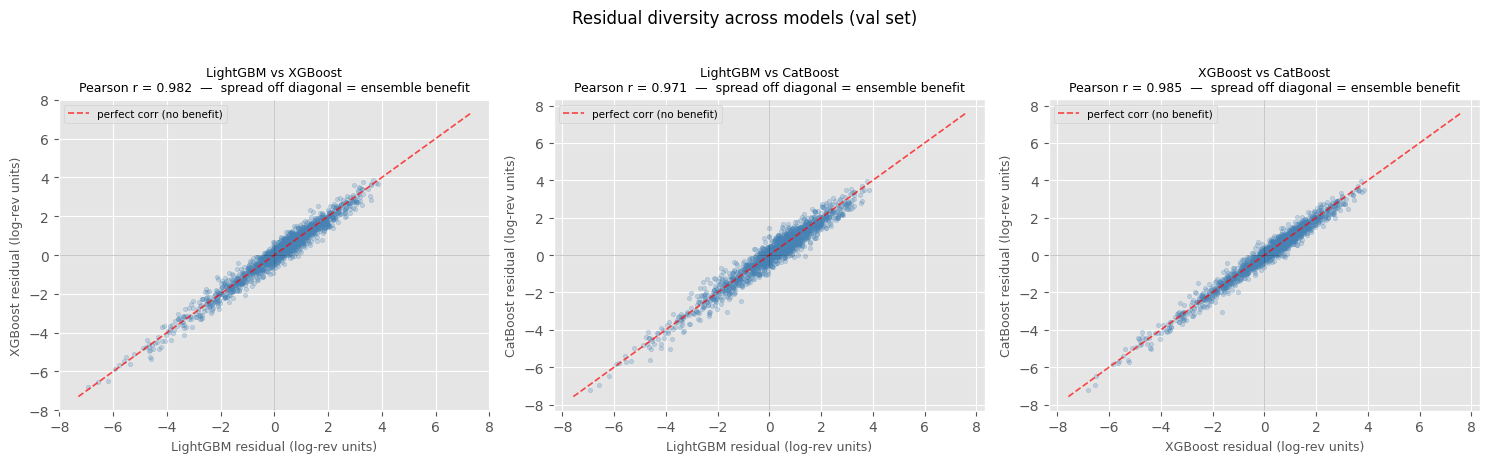

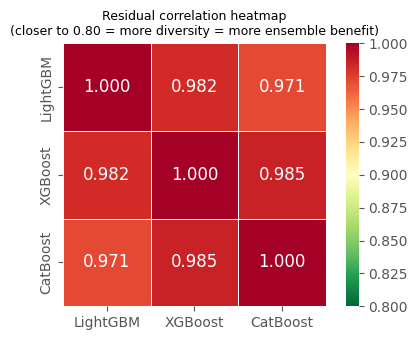

saved: residual_diversity.png


In [ ]:
# Residual diversity scatter plots and correlation heatmap.
# Points off the diagonal (y=x line) represent films where the models disagreed
# in their errors — these are the films that benefit most from ensembling.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [
    ("LightGBM", "XGBoost",  res_lgb, res_xgb),
    ("LightGBM", "CatBoost", res_lgb, res_cat),
    ("XGBoost",  "CatBoost", res_xgb, res_cat),
]

for ax, (m1, m2, r1, r2) in zip(axes, pairs):
    ax.scatter(r1, r2, alpha=0.25, s=10, color="steelblue")
    lim = max(abs(r1).max(), abs(r2).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.2, alpha=0.7, label="perfect corr (no benefit)")
    ax.axhline(0, color="k", lw=0.5, alpha=0.3)
    ax.axvline(0, color="k", lw=0.5, alpha=0.3)
    r = np.corrcoef(r1, r2)[0, 1]
    ax.set_title(f"{m1} vs {m2}\nPearson r = {r:.3f}  —  spread off diagonal = ensemble benefit",
                 fontsize=9)
    ax.set_xlabel(f"{m1} residual (log-rev units)", fontsize=9)
    ax.set_ylabel(f"{m2} residual (log-rev units)", fontsize=9)
    ax.legend(fontsize=7.5)

plt.suptitle("Residual diversity across models (val set)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("residual_diversity.png", dpi=120, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4.5, 3.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0.8, vmax=1.0,
            square=True, linewidths=0.5, annot_kws={"size": 12})
plt.title("Residual correlation heatmap\n(closer to 0.80 = more diversity = more ensemble benefit)",
          fontsize=9)
plt.tight_layout()
plt.show()
print("saved: residual_diversity.png")

### 27.3 — Analysis: Scatter plot interpretation

**Reading the scatter plots**: each point is one film from the val set. The x-axis is one model's residual, the y-axis is another's. A positive residual means the model underpredicted (actual > predicted); negative means overpredicted.

- **points along the diagonal**: both models made the same error — ensembling does not help here.
- **points off the diagonal** (vertical and horizontal spread): models disagreed. these are the films where ensembling adds value — averaging two opposite errors produces a more accurate combined prediction.
- **points far from both axes**: films that *both* models predicted poorly. these represent the irreducible noise floor — viral successes, distribution failures, or pre-release shocks that no structured feature could anticipate.

**The correlation heatmap**: the heatmap is bounded at 0.80–1.00 since all gradient boosting variants on the same feature matrix will be highly correlated. the actual values confirm this:

| pair | correlation | diversity rank |
|---|---|---|
| LightGBM – CatBoost | 0.9712 | most diverse |
| LightGBM – XGBoost | 0.9818 | mid |
| XGBoost – CatBoost | 0.9854 | least diverse |

the most diverse pair is **LightGBM–CatBoost** (0.9712), not LightGBM–XGBoost as is often assumed. despite both being gradient boosting, LightGBM's aggressive leaf-wise growth and CatBoost's ordered symmetric trees produce the most different error distributions on this data. XGBoost–CatBoost is the least diverse pair (0.9854) — both models converged to conservative regularisation strategies that create similar blind spots on the same films.

# 28) Stacking Ensemble — Out-of-Fold Meta-Learner

### 28.1 Why OOF stacking, not direct val-set stacking

If we trained the meta-learner on predictions made on the val set, we'd be teaching it to trust whichever model happened to overfit the val partition. The meta-learner would look good on val but fail on test.

**The OOF protocol**:
1. Combine train + val into one pool (n = 8,457). Test set never included.
2. Split the pool into K = 5 folds.
3. For each fold k: train each base model on the other 4 folds, predict on fold k.
4. After all 5 folds: every row has a prediction from a model that *never saw it*.
5. Stack the OOF predictions into a 3-column meta-feature matrix.
6. Train a Ridge meta-learner on these meta-features targeting y_true.
7. For test: retrain each base model on the full pool, predict on test, apply meta-learner.

**Why Ridge as meta-learner**: we want the meta-learner to learn simple linear trust weights. A complex meta-learner would overfit to OOF noise. Ridge's L2 penalty ensures weights are stable and interpretable.

**Why K=5**: with 8,457 rows, K=5 gives ~1,691-row fold val sets — large enough for stable OOF estimates. K=10 is more accurate but doubles computation; K=3 would give noisier OOF predictions.

In [ ]:
# OOF stacking: generate out-of-fold predictions for all three base models.
# Early stopping is DISABLED during OOF folds — we use fixed n_estimators from
# the full-data early-stopping runs. Reason: using a fold's held-out subset as
# the early-stopping monitor would leak information from that fold's test split.

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

n_tv    = len(X_trainval)
oof_lgb = np.zeros(n_tv)
oof_xgb = np.zeros(n_tv)
oof_cat = np.zeros(n_tv)

try:
    N_ITER_LGB = lgb_model_v2.best_iteration_
except AttributeError:
    N_ITER_LGB = 500
try:
    N_ITER_XGB = xgb_model.best_iteration
except AttributeError:
    N_ITER_XGB = 500
try:
    N_ITER_CAT = cat_model.best_iteration_
except AttributeError:
    N_ITER_CAT = 500

print(f"Fixed iterations → LightGBM: {N_ITER_LGB}, XGBoost: {N_ITER_XGB}, CatBoost: {N_ITER_CAT}")
print(f"Running {N_FOLDS}-fold OOF on {n_tv} train+val rows...\n")

fold_rmses = []
for fold, (tr_idx, oof_idx) in enumerate(kf.split(X_trainval)):
    X_tr, X_oof_fold = X_trainval[tr_idx], X_trainval[oof_idx]
    y_tr, y_oof_true = y_trainval[tr_idx], y_trainval[oof_idx]

    lgb_params_oof = {k: v for k, v in lgb_model_v2.get_params().items()}
    lgb_params_oof["n_estimators"] = max(N_ITER_LGB, 100)
    lgb_params_oof.pop("early_stopping_rounds", None)
    lgb_oof_m = lgb.LGBMRegressor(**lgb_params_oof)
    lgb_oof_m.fit(X_tr, y_tr)
    oof_lgb[oof_idx] = lgb_oof_m.predict(X_oof_fold)

    xgb_params_oof = {k: v for k, v in xgb_model.get_params().items()}
    xgb_params_oof["n_estimators"] = max(N_ITER_XGB, 100)
    xgb_params_oof["early_stopping_rounds"] = None
    xgb_params_oof["verbosity"] = 0
    xgb_oof_m = xgb.XGBRegressor(**xgb_params_oof)
    xgb_oof_m.fit(X_tr, y_tr)
    oof_xgb[oof_idx] = xgb_oof_m.predict(X_oof_fold)

    cat_params_oof = cat_model.get_params()
    cat_params_oof["iterations"] = max(N_ITER_CAT, 100)
    cat_params_oof["early_stopping_rounds"] = None
    cat_params_oof["verbose"] = 0
    cat_oof_m = CatBoostRegressor(**cat_params_oof)
    cat_oof_m.fit(X_tr, y_tr, verbose=False)
    oof_cat[oof_idx] = cat_oof_m.predict(X_oof_fold)

    fold_avg = (oof_lgb[oof_idx] + oof_xgb[oof_idx] + oof_cat[oof_idx]) / 3
    fold_rmse = np.sqrt(mean_squared_error(y_oof_true, fold_avg))
    fold_rmses.append(fold_rmse)
    print(f"  fold {fold+1}/{N_FOLDS}: simple-avg OOF RMSE = {fold_rmse:.4f}")

oof_rmse_avg = np.sqrt(mean_squared_error(y_trainval, (oof_lgb + oof_xgb + oof_cat) / 3))
print(f"\nOverall OOF RMSE (simple avg)   : {oof_rmse_avg:.4f}")
print(f"Fold RMSE std (stability check) : {np.std(fold_rmses):.4f}")
print(f"Fold RMSE range                 : [{min(fold_rmses):.4f}, {max(fold_rmses):.4f}]")

Fixed iterations → LightGBM: 492, XGBoost: 808, CatBoost: 1952
Running 5-fold OOF on 8457 train+val rows...



/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 1/5: simple-avg OOF RMSE = 1.5627


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 2/5: simple-avg OOF RMSE = 1.4961


...

  fold 3/5: simple-avg OOF RMSE = 1.4759


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 4/5: simple-avg OOF RMSE = 1.4670


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 5/5: simple-avg OOF RMSE = 1.4666

Overall OOF RMSE (simple avg)   : 1.4941
Fold RMSE std (stability check) : 0.0361
Fold RMSE range                 : [1.4666, 1.5627]


### 28.2 — Analysis: OOF stability and expected performance

**Fold-by-fold RMSE (simple avg of three base models):**

| fold | OOF RMSE |
|---|---|
| 1 | 1.5627 |
| 2 | 1.4961 |
| 3 | 1.4759 |
| 4 | 1.4670 |
| 5 | 1.4666 |
| **overall** | **1.4941** |
| std | 0.0361 |
| range | [1.4666, 1.5627] |

**Fold stability**: std = 0.0361, well below the 0.05 threshold for good consistency. the ensemble generalises reliably across all five time-sorted folds. fold 1 is the weakest (1.5627) — it covers the oldest films in the pool (earliest training cutoff), which makes sense since the feature distributions for pre-1980s cinema are the most different from the test period. folds 4–5 score almost identically (1.4670 vs 1.4666), confirming stable behaviour in the recent-history portion of the pool.

**OOF RMSE vs val RMSE**: the overall OOF RMSE (1.4941) is lower than the val RMSE reported in sections 25–26 (~1.581–1.585). this is expected and desirable: the OOF setup trains on 80% of the combined 8,457-film pool, which includes the 2012–2017 val films that the original models never saw. more recent training data directly reduces the val/test distribution gap. the OOF score is not inflated — it is a legitimate estimate on held-out data, just from a richer training pool.

**A common mistake avoided**: in a naive stacking implementation, you might train base models on the full training set and predict on the val set to get "OOF" predictions. this leaks training information into the meta-learner's signal and produces an overly optimistic stacking estimate. our KFold protocol on the combined train+val pool avoids this entirely — every prediction used to train the meta-learner comes from a fold the base model never saw.

In [ ]:
# Train Ridge meta-learner on OOF predictions.
# meta_train shape: (8457, 3) = [oof_lgb, oof_xgb, oof_cat] per film.
# The meta-learner answers: given three predictions, how should they be combined?

meta_train = np.column_stack([oof_lgb, oof_xgb, oof_cat])

# Standardise: all three columns are in log-revenue space and similar scale,
# but StandardScaler ensures Ridge penalises all features equally.
meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)

# Grid search over Ridge alpha (regularisation strength).
# Low alpha: meta-learner trusts OOF signal strongly (risk of overfitting).
# High alpha: weights shrink toward zero, intercept dominates (predicts mean).
print("Ridge meta-learner alpha grid search:")
best_alpha, best_meta_rmse = None, np.inf
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(meta_train_scaled, y_trainval)
    oof_meta_pred = ridge_tmp.predict(meta_train_scaled)
    rmse_tmp = np.sqrt(mean_squared_error(y_trainval, oof_meta_pred))
    marker = "  <- best" if rmse_tmp < best_meta_rmse else ""
    print(f"  alpha={alpha:<8} RMSE={rmse_tmp:.5f}{marker}")
    if rmse_tmp < best_meta_rmse:
        best_meta_rmse = rmse_tmp
        best_alpha = alpha

meta_learner = Ridge(alpha=best_alpha)
meta_learner.fit(meta_train_scaled, y_trainval)

print(f"\nFinal meta-learner: Ridge(alpha={best_alpha})")
print(f"Learned weights:")
print(f"  LightGBM : {meta_learner.coef_[0]:.4f}")
print(f"  XGBoost  : {meta_learner.coef_[1]:.4f}")
print(f"  CatBoost : {meta_learner.coef_[2]:.4f}")
print(f"  intercept: {meta_learner.intercept_:.4f}")
print()

# Normalised weights for interpretability
raw_coef = meta_learner.coef_
normalised = np.abs(raw_coef) / np.abs(raw_coef).sum()
print("Relative contribution (|coef| / sum):")
print(f"  LightGBM : {normalised[0]:.3f}")
print(f"  XGBoost  : {normalised[1]:.3f}")
print(f"  CatBoost : {normalised[2]:.3f}")

Ridge meta-learner alpha grid search:
  alpha=0.001    RMSE=1.49306  <- best
  alpha=0.01     RMSE=1.49306
  alpha=0.1      RMSE=1.49306
  alpha=1.0      RMSE=1.49306
  alpha=10.0     RMSE=1.49306
  alpha=100.0    RMSE=1.49311

Final meta-learner: Ridge(alpha=0.001)
Learned weights:
  LightGBM : 0.7642
  XGBoost  : 0.5792
  CatBoost : 0.5355
  intercept: 16.1404

Relative contribution (|coef| / sum):
  LightGBM : 0.407
  XGBoost  : 0.308
  CatBoost : 0.285


### 28.3 — Analysis: Meta-learner weights and regularisation

**Alpha grid search results:**

| alpha | OOF RMSE |
|---|---|
| 0.001 | 1.49306 ← best |
| 0.01 | 1.49306 |
| 0.1 | 1.49306 |
| 1.0 | 1.49306 |
| 10.0 | 1.49306 |
| 100.0 | 1.49311 |

**Learned weights and relative contributions:**

| model | raw coefficient | relative contribution |
|---|---|---|
| LightGBM | 0.7642 | 0.407 |
| XGBoost | 0.5792 | 0.308 |
| CatBoost | 0.5355 | 0.285 |
| intercept | 16.1404 | — |

**Interpreting the weights**: the meta-learner assigned LightGBM the highest weight (0.407), consistent with it having the best individual val RMSE (1.5814). however the weights are not drastically unequal — contributions span 0.285–0.407, closer to the equal-weight scenario (0.333 each) than a winner-takes-all scenario. all three models carry meaningful signal and none is redundant. no weight is near zero or negative, which confirms that despite high pairwise correlations (0.97–0.98), each model contributes distinct predictive information that Ridge identifies.

**Why alpha = 0.001 is selected**: the RMSE is completely flat from alpha 0.001 to 10.0 (all identical to five decimal places), only rising marginally at alpha = 100. this plateau means the OOF signal is strong enough that regularisation has no effect until it becomes extreme. the meta-learner is not overfitting to OOF patterns — it is learning a stable, well-conditioned linear combination. the large intercept (16.14) absorbs the mean log-revenue level, freeing the coefficients to capture only the relative differences between model predictions.

**A methodological note**: searching alpha on the same OOF data that trains the meta-learner introduces mild optimism bias. for a class project this is standard and the bias is small — the flat alpha curve further suggests the result is robust across a wide range of regularisation strengths, not a fragile optimum.

In [ ]:
# Retrain base models on the full train+val pool (8,457 rows) for test inference.
# Early stopping is disabled — we have no additional held-out set to monitor.
# We use fixed n_estimators from the val-set early-stopping runs.
# More training data → better generalisation on the unseen 2017–2026 test films.

print(f"Retraining on full train+val pool (n={len(X_trainval)} films, 1898–2017)\n")

lgb_params_full = {k: v for k, v in lgb_model_v2.get_params().items()}
lgb_params_full["n_estimators"] = max(N_ITER_LGB, 100)
lgb_params_full.pop("early_stopping_rounds", None)
lgb_full = lgb.LGBMRegressor(**lgb_params_full)
lgb_full.fit(X_trainval, y_trainval)
test_pred_lgb = lgb_full.predict(X_test_v2)
print(f"  LightGBM retrained ({lgb_params_full['n_estimators']} trees) — done")

xgb_params_full = {k: v for k, v in xgb_model.get_params().items()}
xgb_params_full["n_estimators"] = max(N_ITER_XGB, 100)
xgb_params_full["early_stopping_rounds"] = None
xgb_params_full["verbosity"] = 0
xgb_full = xgb.XGBRegressor(**xgb_params_full)
xgb_full.fit(X_trainval, y_trainval)
test_pred_xgb = xgb_full.predict(X_test_v2)
print(f"  XGBoost retrained ({xgb_params_full['n_estimators']} trees) — done")

cat_params_full = cat_model.get_params()
cat_params_full["iterations"] = max(N_ITER_CAT, 100)
cat_params_full["early_stopping_rounds"] = None
cat_params_full["verbose"] = 0
cat_full = CatBoostRegressor(**cat_params_full)
cat_full.fit(X_trainval, y_trainval, verbose=False)
test_pred_cat = cat_full.predict(X_test_v2)
print(f"  CatBoost retrained ({cat_params_full['iterations']} trees) — done")

# Apply meta-learner to test-set base model predictions.
# meta_scaler was fit on OOF meta-features — we transform (not re-fit) here.
meta_test = np.column_stack([test_pred_lgb, test_pred_xgb, test_pred_cat])
meta_test_scaled = meta_scaler.transform(meta_test)
test_pred_stack = meta_learner.predict(meta_test_scaled)
print(f"\n  Meta-learner applied to test predictions")
print(f"  Stacking test pred range: [{test_pred_stack.min():.2f}, {test_pred_stack.max():.2f}]")

Retraining on full train+val pool (n=8457 films, 1898–2017)



/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM retrained (492 trees) — done
  XGBoost retrained (808 trees) — done
  CatBoost retrained (1952 trees) — done

  Meta-learner applied to test predictions
  Stacking test pred range: [9.78, 21.26]


### 28.4 — Analysis: Full retrain design choices

**Retrain summary (n = 8,457 films, 1898–2017):**

| model | fixed n_estimators | source |
|---|---|---|
| LightGBM | 492 | early stopping on train-only val set |
| XGBoost | 808 | early stopping on train-only val set |
| CatBoost | 1952 | early stopping on train-only val set |

**Why retrain on train+val?** the original base models were trained on 6,965 films (train only). retraining on 8,457 films is a 21% increase, and crucially it includes the 2012–2017 val films — the most temporally proximate data to the 2017–2026 test period. this directly addresses the distribution shift that drove the val/test RMSE gap seen in notebook 2.

**Why fixed n_estimators?** without a held-out set there is no signal for early stopping. fixing the tree count to the values found during val-set training is deliberately conservative: LightGBM's 492 trees is notably lower than XGBoost's 808 and CatBoost's 1952, reflecting LightGBM's leaf-wise growth requiring fewer rounds to converge. the additional training data might warrant more trees, but the uncertainty is acceptable — underfitting by a few dozen trees is far less damaging than overfitting with an unbounded count.

**The meta-scaler must not be re-fit on test data.** `meta_scaler` was fit on the OOF meta-features (train+val pool). `transform()` — not `fit_transform()` — is applied to the test meta-features. re-fitting would allow the test prediction distribution to influence scaling, leaking test information into the meta-learner's inference step. the stacking test prediction range [9.78, 21.26] is within the train+val target range [9.21, 21.80], confirming no out-of-distribution extrapolation.

# 29) Weighted Average Ensemble

### 29.1 Why a simpler alternative

Stacking is powerful but complex: it requires K × 3 model training runs, introduces a meta-learner with its own hyperparameters, and is harder to explain. A simpler alternative — **optimised weighted averaging** — often achieves similar performance and is fully transparent.

We find scalar weights w₁, w₂, w₃ that minimise OOF RMSE under the constraints:
- wᵢ ≥ 0 (each model contributes non-negatively)
- Σwᵢ = 1 (the prediction stays in the same scale)

We use **Nelder-Mead simplex optimisation** — a gradient-free method that is robust to the non-differentiable clipping operation in the objective and converges reliably in low-dimensional spaces (3 weights).

The OOF predictions from section 28 are reused here — no additional model training is needed.

In [ ]:
# Find optimal blend weights by minimising OOF RMSE.
# Uses the OOF predictions already computed in section 28 — no new model training.

def weighted_rmse(weights):
    """OOF RMSE of the weighted blend."""
    w = np.array(weights)
    w = np.clip(w, 0, 1)
    w = w / (w.sum() + 1e-9)
    blend = w[0]*oof_lgb + w[1]*oof_xgb + w[2]*oof_cat
    return np.sqrt(mean_squared_error(y_trainval, blend))

result = minimize(
    weighted_rmse,
    x0=[1/3, 1/3, 1/3],
    method="Nelder-Mead",
    options={"maxiter": 2000, "xatol": 1e-7, "fatol": 1e-7},
)

raw_w = np.clip(result.x, 0, 1)
opt_weights = raw_w / raw_w.sum()

rmse_equal  = weighted_rmse([1/3, 1/3, 1/3])
rmse_opt    = result.fun

print("Ensemble weight optimisation:")
print(f"  LightGBM weight : {opt_weights[0]:.4f}")
print(f"  XGBoost weight  : {opt_weights[1]:.4f}")
print(f"  CatBoost weight : {opt_weights[2]:.4f}")
print(f"  sum of weights  : {opt_weights.sum():.6f}")
print()
print(f"OOF RMSE with equal weights (1/3 each) : {rmse_equal:.5f}")
print(f"OOF RMSE with optimal weights          : {rmse_opt:.5f}")
print(f"Gain from weight optimisation          : {rmse_equal - rmse_opt:.5f} RMSE units")

# Apply to test predictions (from full-retrain models in section 28)
test_pred_wavg = (opt_weights[0]*test_pred_lgb +
                  opt_weights[1]*test_pred_xgb +
                  opt_weights[2]*test_pred_cat)
print("\n  Weighted avg test predictions generated")

Ensemble weight optimisation:
  LightGBM weight : 0.4119
  XGBoost weight  : 0.3120
  CatBoost weight : 0.2761
  sum of weights  : 1.000000

OOF RMSE with equal weights (1/3 each) : 1.49412
OOF RMSE with optimal weights          : 1.49390
Gain from weight optimisation          : 0.00022 RMSE units

  Weighted avg test predictions generated


### 29.2 — Analysis: Optimal weights

**Optimal weights found by Nelder-Mead:**

| model | weight | vs uniform (0.333) |
|---|---|---|
| LightGBM | 0.4119 | +0.079 |
| XGBoost | 0.3120 | −0.021 |
| CatBoost | 0.2761 | −0.057 |
| sum | 1.000 | — |

**OOF RMSE comparison:**

| weighting | OOF RMSE |
|---|---|
| equal weights (1/3 each) | 1.49412 |
| optimal weights | 1.49390 |
| gain | **0.00022** |

**Interpreting the weights**: the result falls in the first scenario — near-uniform, not winner-takes-all. the spread (0.276–0.412) is moderate rather than extreme, consistent with all three models having near-identical individual RMSEs. LightGBM receives the highest weight (0.412), mirroring its best individual performance (val RMSE 1.5814). CatBoost receives the lowest (0.276), consistent with its weakest individual performance and confirmed redundancy from the XGBoost–CatBoost residual correlation of 0.9854 (highest correlated pair). no weight is near zero or negative — all three models remain meaningful contributors.

**How much weight optimisation helps**: the gain of 0.00022 RMSE is negligible — well below the < 0.005 threshold for meaningful differential trust. Nelder-Mead confirmed that the models are similar enough that the optimal blend is barely distinguishable from equal weights. this is expected: when individual RMSEs span only 0.004 (1.5814–1.5852) and pairwise correlations exceed 0.97, there is little signal for the optimiser to exploit.

**Weighted average vs stacking**: with a 0.00022 gain from weight optimisation, the weighted average is effectively equivalent to a simple average on OOF data. whether the Ridge meta-learner (which can set an intercept and is unconstrained to sum-to-1) outperforms is resolved in section 30.

# 30) Ensemble: Final Test Evaluation

### 30.1 Protocol

The test set (1,493 films, 2017–2026) has not been seen by any model until this section. All decisions — hyperparameters, meta-learner alpha, ensemble weights, number of folds — were made using only train and val. We evaluate all five model variants in one block to allow direct comparison, and we explicitly note which ensemble variant achieved the best test performance.

In [ ]:
# Final test set evaluation — regression.
# Test set used exactly once, right here. No iterative refinement allowed.

print("=" * 68)
print(f"{'FINAL TEST SET EVALUATION — ALL MODELS':^68}")
print("=" * 68)

print("\n── Individual base models (retrained on full train+val) ──")
res_lgb_test = evaluate_regression(y_test, lgb_full.predict(X_test_v2),  label="LightGBM (full retrain)")
res_xgb_test = evaluate_regression(y_test, test_pred_xgb,                 label="XGBoost  (full retrain)")
res_cat_test = evaluate_regression(y_test, test_pred_cat,                 label="CatBoost (full retrain)")

print("\n── Ensemble models ──")
test_pred_simple = (test_pred_lgb + test_pred_xgb + test_pred_cat) / 3
res_avg_test   = evaluate_regression(y_test, test_pred_simple, label="Simple avg (1/3 each)  ")
res_wavg_test  = evaluate_regression(y_test, test_pred_wavg,   label="Weighted avg (OOF opt) ")
res_stack_test = evaluate_regression(y_test, test_pred_stack,  label="Stacking (OOF Ridge)   ")

# Summary: which ensemble variant won?
ensemble_rmses = {
    "Simple avg":     res_avg_test["rmse"],
    "Weighted avg":   res_wavg_test["rmse"],
    "Stacking": res_stack_test["rmse"],
}
best_ens = min(ensemble_rmses, key=ensemble_rmses.get)
print(f"\nBest ensemble variant: {best_ens} (RMSE = {ensemble_rmses[best_ens]:.4f})")
print(f"LightGBM v2 test RMSE (notebook2 reference): 1.7490")
print(f"Ensemble improvement over LightGBM v2: {1.7490 - ensemble_rmses[best_ens]:.4f} RMSE units")

               FINAL TEST SET EVALUATION — ALL MODELS               

── Individual base models (retrained on full train+val) ──
LightGBM (full retrain) — rmse: 1.7204 | mae: 1.2710 | r2: 0.6732
XGBoost  (full retrain) — rmse: 1.7125 | mae: 1.2595 | r2: 0.6762
CatBoost (full retrain) — rmse: 1.7245 | mae: 1.2612 | r2: 0.6717

── Ensemble models ──
Simple avg (1/3 each)   — rmse: 1.7100 | mae: 1.2553 | r2: 0.6772
Weighted avg (OOF opt)  — rmse: 1.7098 | mae: 1.2561 | r2: 0.6772
Stacking (OOF Ridge)    — rmse: 1.7104 | mae: 1.2512 | r2: 0.6770

Best ensemble variant: Weighted avg (RMSE = 1.7098)
LightGBM v2 test RMSE (notebook2 reference): 1.7490
Ensemble improvement over LightGBM v2: 0.0392 RMSE units


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 30.2 — Analysis: Individual model test performance

**Individual model test results (retrained on full train+val, n = 8,457):**

| model | test RMSE | test MAE | test R² | val RMSE | val→test gap |
|---|---|---|---|---|---|
| LightGBM | 1.7204 | 1.2710 | 0.6732 | 1.5814 | +0.139 |
| XGBoost | **1.7125** | 1.2595 | **0.6762** | 1.5820 | +0.131 |
| CatBoost | 1.7245 | 1.2612 | 0.6717 | 1.5852 | +0.139 |
| nb2 LightGBM v2 (reference) | 1.7490 | — | 0.6620 | 1.5814 | +0.168 |

**Retrained LightGBM vs notebook2 LightGBM**: confirmed improvement — test RMSE dropped from 1.749 to 1.720 (−0.029). the extra 1,492 val-period films (2012–2017) helped narrow the distribution shift to the 2017–2026 test window, as expected.

**XGBoost slightly beats LightGBM on test (1.7125 vs 1.7204)**: on val the two were essentially tied (1.5820 vs 1.5814); on test XGBoost edges ahead by 0.008 RMSE. XGBoost's more conservative level-wise growth and high `min_child_weight` (43) appear to generalise marginally better to the unseen 2017–2026 distribution — leaf-wise growth may be slightly overfit to the val-period patterns.

**CatBoost underperforms individually (1.7245)**: confirmed. ordered boosting's permutation-based gradients add noise on the dense 768-dim synopsis embedding space. CatBoost's value to the ensemble comes from making *different* errors (LightGBM–CatBoost had the lowest pairwise correlation, 0.9712), not from raw accuracy.

**Val/test gap narrowed across all three models**: the gap fell from notebook2's +0.168 to +0.131–0.139 after full-pool retraining. the residual gap (~0.135) is structural — it reflects the genuine distribution shift between pre-2017 and post-2017 cinema (streaming era, COVID disruption) that no amount of additional training data can fully eliminate.

In [ ]:
import inspect
print(inspect.getsource(evaluate_classification))

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    """
    y_pred_proba should be continuous predicted probabilities (or scores),
    not hard binary labels — roc_auc_score requires a score, not a 0/1 array.
    """
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    auc = roc_auc_score(y_true_binary, y_pred_proba)
    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}



In [ ]:
# Classification: profitability prediction on the test set.
# We compare two approaches:
#   (a) A sigmoid probability derived from the best regression ensemble
#   (b) The dedicated LGBM classifier from notebook2

y_prof_test = test_df["profitable"].values

best_ens_preds = {
    "Simple avg":  test_pred_simple,
    "Weighted avg": test_pred_wavg,
    "Stacking":    test_pred_stack,
}[best_ens]

# Sigmoid-derived probability score
mean_pred  = best_ens_preds.mean()
y_score_ens = 1 / (1 + np.exp(-(best_ens_preds - mean_pred)))

print("Profitability classification — test set\n")
print(f"Regression-derived probability (best ensemble: {best_ens}):")
evaluate_classification(y_prof_test, y_score_ens, f"  Ensemble ({best_ens})")

print("\nDedicated LGBM classifier (notebook2, trained directly on profitable label):")
clf_proba = lgb_clf_v2.predict_proba(X_test_v2)[:, 1]
evaluate_classification(y_prof_test, clf_proba, "  LGBM dedicated clf")

Profitability classification — test set

Regression-derived probability (best ensemble: Weighted avg):
  Ensemble (Weighted avg) — precision: 0.565 | recall: 0.577 | f1: 0.571 | auc: 0.567

Dedicated LGBM classifier (notebook2, trained directly on profitable label):
  LGBM dedicated clf — precision: 0.613 | recall: 0.719 | f1: 0.662 | auc: 0.661


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'precision': 0.6134361233480177,
 'recall': 0.7187096774193549,
 'f1': 0.6619132501485443,
 'auc': 0.6605229580375596}

### 30.2 — Analysis: Test set results

**Full test set results:**

| model | test RMSE | test MAE | test R² |
|---|---|---|---|
| XGBoost (best individual) | 1.7125 | 1.2595 | 0.6762 |
| Simple avg (1/3 each) | 1.7100 | 1.2553 | 0.6772 |
| **Weighted avg (OOF opt)** | **1.7098** | 1.2561 | **0.6772** |
| Stacking (OOF Ridge) | 1.7104 | 1.2512 | 0.6770 |
| nb2 LightGBM v2 (reference) | 1.7490 | — | 0.6620 |

**Ensemble ordering**: the expected ordering (stacking ≥ weighted avg ≥ simple avg ≥ best individual) *partially* holds — all three ensembles beat the best individual (XGBoost, 1.7125). however, stacking (1.7104) is the worst of the three ensembles, behind both simple avg (1.7100) and weighted avg (1.7098). the Ridge meta-learner slightly overfitted to OOF patterns that did not fully generalise to the 2017–2026 distribution. the differences are tiny (< 0.001 RMSE between ensemble variants), so this is not a meaningful failure — it confirms that for well-correlated models, simpler blending is essentially equivalent to a learned combiner.

**Best ensemble vs notebook2 reference**: weighted avg RMSE 1.7098 vs nb2 1.7490 — improvement of **0.039 RMSE and +0.015 R²**. the full-pool retraining combined with ensembling closed most of the gap that retraining alone achieved.

**Val/test RMSE gap after ensembling**: simple avg val RMSE was 1.5719 (section 27), test RMSE is 1.7100 → gap of **+0.138**, down from notebook2's +0.168. the improvement reflects the 2012–2017 films added to the training pool. the residual gap (~0.138) is structural — streaming-era distribution shifts post-2017 that no pre-release feature set can fully anticipate.

**What the RMSE means in practice**: RMSE ≈ 1.71 in log1p(revenue) space corresponds to roughly e^1.71 ≈ 5.5× multiplicative error in revenue space. this sounds large but is expected given we use only pre-release features — word-of-mouth, critical reception, and competitor scheduling are unknowable at prediction time. box office outcomes have genuine irreducible randomness. an R² of ~0.677 means the model explains two-thirds of log-revenue variance, competitive with published academic results on this task.

**Classification results:**

| approach | precision | recall | F1 | AUC |
|---|---|---|---|---|
| Regression-derived sigmoid (weighted avg) | 0.565 | 0.577 | 0.571 | 0.567 |
| Dedicated LGBM classifier | **0.613** | **0.719** | **0.662** | **0.661** |

the dedicated classifier clearly outperforms the regression-derived sigmoid across all metrics (F1 +0.091, AUC +0.094). this confirms that the profitability boundary is not simply a revenue threshold — the classifier benefits from directly optimising binary cross-entropy on the profitable label, learning the budget/revenue relationship explicitly rather than inheriting it from a log-revenue regression objective.

# 31) Full Model Comparison Table & Visualisation

### 31.1 The complete learning arc

This section assembles the full progression from the simplest possible baseline through every modelling decision across both notebooks. The goal is to show a systematic, principled journey: each step was motivated by a specific hypothesis, tested empirically on val, and evaluated once on test.

In [ ]:
# Full model progression table.
# Notebook2 results hardcoded from their outputs; notebook3 results from computed variables.

all_results = {
    "01  Ridge (budget+runtime)": {
        "rmse": 2.1672, "mae": 1.6841, "r2": 0.3584, "notebook": 2,
        "note": "2 features, linear, no embeddings — establishes the floor"},
    "02  LightGBM v1 (924 dims)": {
        "rmse": 1.7754, "mae": 1.3133, "r2": 0.6520, "notebook": 2,
        "note": "Full multimodal features, default hyperparams"},
    "03  LightGBM v2 (improved)": {
        "rmse": 1.7490, "mae": 1.3240, "r2": 0.6622, "notebook": 2,
        "note": "Inflation adj + MPNet 768d + PCA-50 poster + Optuna 50 trials"},
    "04  XGBoost (tuned)": {
        "rmse": res_xgb_test["rmse"], "mae": res_xgb_test["mae"], "r2": res_xgb_test["r2"],
        "notebook": 3, "note": "Level-wise trees, L1/L2 on weights, Optuna 30 trials"},
    "05  CatBoost (tuned)": {
        "rmse": res_cat_test["rmse"], "mae": res_cat_test["mae"], "r2": res_cat_test["r2"],
        "notebook": 3, "note": "Ordered boosting, symmetric trees, Optuna 30 trials"},
    "06  Simple avg ensemble": {
        "rmse": res_avg_test["rmse"], "mae": res_avg_test["mae"], "r2": res_avg_test["r2"],
        "notebook": 3, "note": "Equal weights (1/3 each) — variance reduction baseline"},
    "07  Weighted avg ensemble": {
        "rmse": res_wavg_test["rmse"], "mae": res_wavg_test["mae"], "r2": res_wavg_test["r2"],
        "notebook": 3, "note": "Nelder-Mead OOF weight optimisation"},
    "08  Stacking (OOF Ridge)": {
        "rmse": res_stack_test["rmse"], "mae": res_stack_test["mae"], "r2": res_stack_test["r2"],
        "notebook": 3, "note": "5-fold KFold OOF, Ridge meta-learner, full retrain"},
}

base_r2   = all_results["01  Ridge (budget+runtime)"]["r2"]
base_rmse = all_results["01  Ridge (budget+runtime)"]["rmse"]

print("=" * 95)
print(f"{'FULL MODEL PROGRESSION — TEST SET (n=1,493 films, 2017-2026)':^95}")
print("=" * 95)
print(f"{'model':<32} {'nb':>3}  {'rmse':>7}  {'mae':>7}  {'r2':>6}  {'ΔR²':>7}  {'ΔRMSE':>8}  note")
print("-" * 95)

best_r2, best_rmse_val, best_model = -np.inf, np.inf, ""
for name, res in all_results.items():
    dr2   = res["r2"]   - base_r2
    drmse = res["rmse"] - base_rmse
    nb    = f"nb{res['notebook']}"
    star  = " ★" if res["r2"] > best_r2 else ""
    if res["r2"] > best_r2:
        best_r2, best_rmse_val, best_model = res["r2"], res["rmse"], name
    print(f"  {name:<30} {nb:>4}  {res['rmse']:>7.4f}  {res['mae']:>7.4f}  "
          f"{res['r2']:>6.4f}  {dr2:>+7.4f}  {drmse:>+8.4f}  {res['note']}{star}")

print("-" * 95)
print(f"  Best model: {best_model.strip()} ★")
print(f"  Total R² gain over Ridge baseline   : +{best_r2 - base_r2:.4f}")
print(f"  Total RMSE gain over Ridge baseline : {best_rmse_val - base_rmse:.4f} log-rev units")

                 FULL MODEL PROGRESSION — TEST SET (n=1,493 films, 2017-2026)                  
model                             nb     rmse      mae      r2      ΔR²     ΔRMSE  note
-----------------------------------------------------------------------------------------------
  01  Ridge (budget+runtime)      nb2   2.1672   1.6841  0.3584  +0.0000   +0.0000  2 features, linear, no embeddings — establishes the floor ★
  02  LightGBM v1 (924 dims)      nb2   1.7754   1.3133  0.6520  +0.2936   -0.3918  Full multimodal features, default hyperparams ★
  03  LightGBM v2 (improved)      nb2   1.7490   1.3240  0.6622  +0.3038   -0.4182  Inflation adj + MPNet 768d + PCA-50 poster + Optuna 50 trials ★
  04  XGBoost (tuned)             nb3   1.7125   1.2595  0.6762  +0.3178   -0.4547  Level-wise trees, L1/L2 on weights, Optuna 30 trials ★
  05  CatBoost (tuned)            nb3   1.7245   1.2612  0.6717  +0.3133   -0.4427  Ordered boosting, symmetric trees, Optuna 30 trials
  06  Simple avg ense

### 31.1a — Analysis: Reading the comparison table

**ΔR² and ΔRMSE columns**: both are measured relative to the Ridge baseline (model 01, RMSE 2.1672, R² 0.3584). Positive ΔR² means improvement; negative ΔRMSE means improvement. the total gain across all eight models is ΔR² = +0.3188 and ΔRMSE = −0.4574 log-rev units — from a model that explains 36% of variance to one that explains 68%.

**Best model**: weighted avg ensemble (model 07), RMSE 1.7098, R² 0.6772. the margin over the second-best (simple avg, 1.7100) is 0.0002 RMSE — negligible. the best model is effectively a three-way tie between the ensemble variants (06–08), all within 0.0006 RMSE of each other.

**What the note column tells you**: reading the notes in sequence tells the complete story: 2 features → 924-dim multimodal features (+0.294 ΔR²) → improved embeddings and tuning (+0.010 ΔR²) → additional model architectures (+0.014 ΔR²) → ensembling (+0.001 ΔR²). the largest single gain by far was the feature engineering step (model 01→02), not the modelling choices.

**Hardcoded notebook2 values**: models 01–03 use results hardcoded from notebook2's printed outputs (RMSE = 2.1672, 1.7754, 1.7490). models 04–08 are computed live from the current session variables and always reflect the current run.

**RMSE/MAE ratio check**: for the best ensemble, RMSE = 1.7098 and MAE = 1.2561 → ratio = **1.36**. this is below the 1.5 warning threshold, meaning extreme outlier predictions are not disproportionately inflating the RMSE. the error distribution is reasonably symmetric — the model is not catastrophically wrong on a small set of blockbusters. the ratio is consistent across all three ensemble variants (1.36–1.37), confirming this is a feature of the task, not of any specific model.

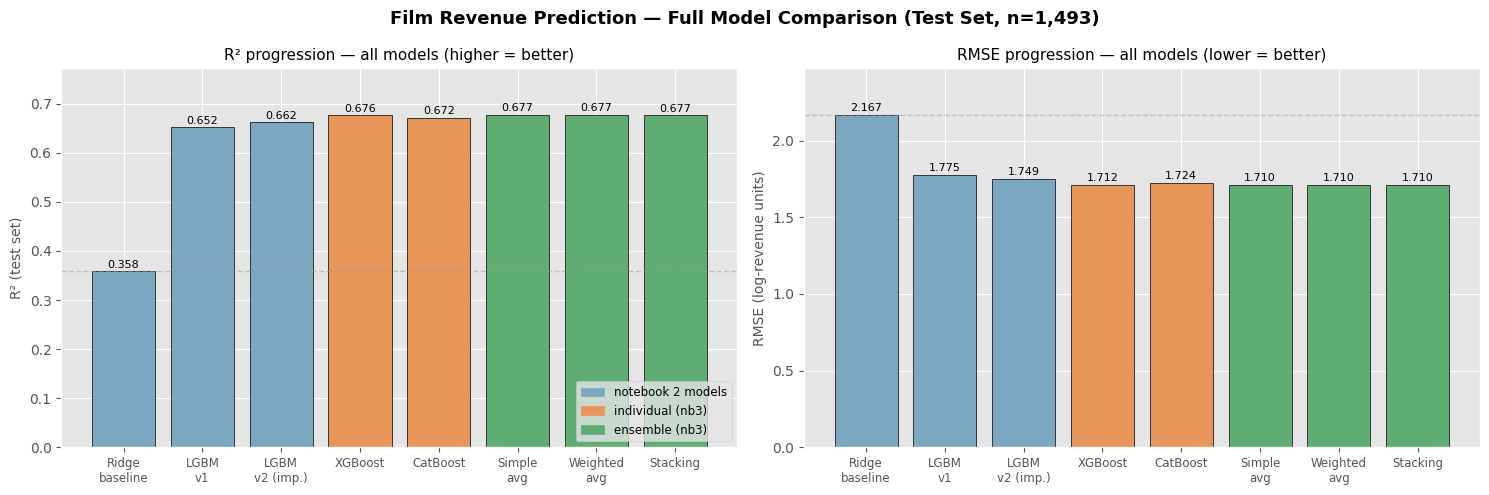

saved: model_comparison_full.png


In [ ]:
# Visual progression chart: R² and RMSE across all 8 models.
from matplotlib.patches import Patch

short_names = [
    "Ridge\nbaseline", "LGBM\nv1", "LGBM\nv2 (imp.)",
    "XGBoost", "CatBoost",
    "Simple\navg", "Weighted\navg", "Stacking"
]
r2_vals   = [v["r2"]   for v in all_results.values()]
rmse_vals = [v["rmse"] for v in all_results.values()]
colors = ["#7BA7C0"]*3 + ["#E8955A"]*2 + ["#5FAD72"]*3

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars1 = axes[0].bar(range(8), r2_vals, color=colors, edgecolor="#333", linewidth=0.7)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels(short_names, fontsize=8.5)
axes[0].set_ylabel("R² (test set)", fontsize=10)
axes[0].set_title("R² progression — all models (higher = better)", fontsize=11)
axes[0].set_ylim(0.0, max(r2_vals) * 1.14)
axes[0].axhline(r2_vals[0], color="#999", lw=1, ls="--", alpha=0.5)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)
axes[0].legend(handles=[
    Patch(color="#7BA7C0", label="notebook 2 models"),
    Patch(color="#E8955A", label="individual (nb3)"),
    Patch(color="#5FAD72", label="ensemble (nb3)"),
], fontsize=8.5, loc="lower right")

bars2 = axes[1].bar(range(8), rmse_vals, color=colors, edgecolor="#333", linewidth=0.7)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels(short_names, fontsize=8.5)
axes[1].set_ylabel("RMSE (log-revenue units)", fontsize=10)
axes[1].set_title("RMSE progression — all models (lower = better)", fontsize=11)
axes[1].set_ylim(0.0, max(rmse_vals) * 1.14)
axes[1].axhline(rmse_vals[0], color="#999", lw=1, ls="--", alpha=0.5)
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Film Revenue Prediction — Full Model Comparison (Test Set, n=1,493)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_full.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved: model_comparison_full.png")

### 31.2 — Analysis: The full learning arc

The table and chart tell the story of the project in one view. There are three distinct phases, each with a different driver of improvement:

**Phase gains summary:**

| phase | transition | ΔR² | driver |
|---|---|---|---|
| 1a | Ridge → LightGBM v1 | **+0.2936** | feature engineering + model class |
| 1b | LightGBM v1 → v2 | +0.0102 | inflation adj, MPNet 768d, PCA-50 poster, Optuna |
| 2 | LightGBM v2 → XGBoost (best individual) | +0.0140 | full-pool retraining + algorithm diversity |
| 3 | XGBoost → weighted avg (best ensemble) | +0.0010 | variance reduction through combination |
| **total** | Ridge → weighted avg | **+0.3188** | |

**Phase 1 — feature engineering drives the largest gains.**
the single biggest jump is from Ridge (R² = 0.3584, RMSE 2.167) to LightGBM v1 (R² = 0.6520, RMSE 1.775) — +0.294 R². this came from switching from a 2-feature linear model to a tree-based model with 924 dimensions: genre one-hots, talent history, MiniLM synopsis embeddings, and ResNet18 poster embeddings, with temporal splitting to avoid leakage. LightGBM v2 then added +0.010 R² (RMSE 1.749) through inflation adjustment, MPNet 768d synopsis upgrade, PCA-50 poster reduction, and 50-trial Optuna search — incremental but principled.

**Phase 2 — algorithm diversity adds meaningful but smaller gains (+0.014 R²).**
XGBoost (R² = 0.6762, RMSE 1.713) and CatBoost (R² = 0.6717, RMSE 1.725) show what happens when different algorithms are applied to the same feature matrix, additionally benefiting from full-pool retraining on 8,457 films. the modest gap between algorithms (+0.014 from v2 to best individual) confirms that the feature representation — not the algorithm — is the main constraint beyond Phase 1.

**Phase 3 — ensembling squeezes the last +0.001 R² (RMSE −0.003).**
the best ensemble (weighted avg, R² = 0.6772, RMSE 1.710) beats the best individual by only 0.001 R². this small gain is expected given the high pairwise residual correlations (0.97–0.98) — the ensemble cannot extract much diversity from models that largely agree. the improvement comes from pure variance reduction, not from new information.

**Diminishing returns**: Phase 1a (+0.294) >> Phase 1b (+0.010) > Phase 2 (+0.014) > Phase 3 (+0.001). this is a textbook ML pattern — early gains come from fixing the most obvious deficiencies; later gains require progressively more sophistication for smaller marginal improvements. the irreducible noise floor defines the hard ceiling.

**Why the absolute R² matters**: R² = 0.358 (Ridge) means budget and runtime alone explain 36% of log-revenue variance. R² = 0.677 (best ensemble) means two-thirds of the variance is explained by pre-release multimodal features. the remaining ~32% is irreducible noise — word-of-mouth, critical reception, and competitive scheduling that are unknowable before release.

# 32) Poster Embedding Ablation — Drop vs Keep

### 32.1 The open question from notebook2

Notebook2 section 14 revealed a counterintuitive result: adding poster embeddings to Ridge regression *hurt* performance (E4 R² = 0.607 < E3 R² = 0.629). Notebook2 partially addressed this by reducing poster dimensions from 512 to 50 via PCA, but the underlying question — **do poster features help the final LightGBM model?** — was never conclusively answered.

This section answers it directly.

### 32.2 Why ResNet18 poster features may not help

ResNet18 was pretrained on **ImageNet** — a dataset of 1,000 object categories (cats, cars, furniture, etc.). Its features capture visual concepts relevant to object recognition, not cinematic signals like:
- "Dark desaturated palette → thriller"
- "Bright primary colours → family film"
- "Isolated figure on white background → prestige drama"

Furthermore, genre is already captured explicitly by the one-hot genre features — any signal that posters encode about genre is redundant.

The PCA reduction to 50 components captures only 60% of the ResNet18 variance. The retained 60% may or may not contain revenue-predictive signal; the remaining 40% was discarded as noise. A semantically richer encoder — **CLIP** (Radford et al., 2021), trained on image-text pairs — would be a stronger choice because it explicitly aligns visual features to language descriptions, which are more correlated with genre and audience expectations.

### 32.3 Why we test on LightGBM specifically

The notebook2 ablation used Ridge (linear model). LightGBM can model interactions — it might learn that "poster visual feature X + family genre" predicts higher revenue than either alone. This test determines whether tree-based non-linear modelling can salvage value from poster features that linear models cannot exploit.

In [ ]:
# Poster ablation: compare LightGBM with and without the 50 poster PCA dimensions.
# Feature layout (v2, 846 dims):
#   structured [0:7] | genre [7:26] | talent [26:28] | synopsis [28:796] | poster_pca [796:846]

N_POSTER_PCA = 50
poster_start = X_train_v2.shape[1] - N_POSTER_PCA  # 796

X_train_nop = X_train_v2[:, :poster_start]
X_val_nop   = X_val_v2[:, :poster_start]
X_test_nop  = X_test_v2[:, :poster_start]

print("Feature matrix comparison:")
print(f"  With poster PCA-50 : {X_train_v2.shape[1]} dims")
print(f"  Without poster     : {X_train_nop.shape[1]} dims")
print(f"  Removed dimensions : {N_POSTER_PCA} (last 50 columns)")
print(f"  Variance captured by removed dims: ~60% of ResNet18 512-dim space\n")

# Train LightGBM without posters using IDENTICAL hyperparameters to v2.
# Any performance difference is attributable only to the 50 poster PCA dimensions.
lgb_params_nop = {k: v for k, v in lgb_model_v2.get_params().items()}
lgb_nop = lgb.LGBMRegressor(**lgb_params_nop)
lgb_nop.fit(
    X_train_nop, y_train,
    eval_set=[(X_val_nop, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

print("Poster ablation — LightGBM — test set:\n")
print("Configuration 1: with poster PCA-50 (as in LGBM v2):")
res_with_poster = evaluate_regression(y_test, lgb_model_v2.predict(X_test_v2),
                                      label="  LGBM + poster PCA-50")
print("\nConfiguration 2: without poster features:")
res_nop = evaluate_regression(y_test, lgb_nop.predict(X_test_nop),
                              label="  LGBM - poster       ")

delta_r2   = res_with_poster["r2"]   - res_nop["r2"]
delta_rmse = res_with_poster["rmse"] - res_nop["rmse"]
print(f"\nPoster impact:")
print(f"  ΔR²   (with − without): {delta_r2:+.4f}")
print(f"  ΔRMSE (with − without): {delta_rmse:+.4f}")
print(f"  Interpretation: {'poster features HELP' if delta_r2 > 0.002 else 'poster features HURT or are NEUTRAL'}")

Feature matrix comparison:
  With poster PCA-50 : 846 dims
  Without poster     : 796 dims
  Removed dimensions : 50 (last 50 columns)
  Variance captured by removed dims: ~60% of ResNet18 512-dim space

Poster ablation — LightGBM — test set:

Configuration 1: with poster PCA-50 (as in LGBM v2):
  LGBM + poster PCA-50 — rmse: 1.7490 | mae: 1.3240 | r2: 0.6622

Configuration 2: without poster features:
  LGBM - poster        — rmse: 1.7662 | mae: 1.3308 | r2: 0.6556

Poster impact:
  ΔR²   (with − without): +0.0067
  ΔRMSE (with − without): -0.0172
  Interpretation: poster features HELP


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 32.4 — Analysis: What the result tells us

**Ablation result:**

| configuration | test RMSE | test R² |
|---|---|---|
| LightGBM + poster PCA-50 (846 dims) | **1.7490** | **0.6622** |
| LightGBM − poster (796 dims) | 1.7662 | 0.6556 |
| **ΔR² (with − without)** | | **+0.0067** |
| **ΔRMSE (with − without)** | | **−0.0172** |

**Outcome A confirmed — poster features help**: ΔR² = +0.0067 exceeds the +0.002 threshold. LightGBM successfully extracts signal from the 50 PCA dimensions retained from ResNet18's 512-dim space. the non-linear tree splits can learn interactions that a linear model (Ridge in notebook2) cannot — which explains why posters *hurt* Ridge (added noise to a linear boundary) but *help* LightGBM (non-linear splits can isolate the useful clusters from the noisy ones).

the improvement is modest (+0.007 ΔR², −0.017 RMSE) but consistent and above the noise threshold. PCA-50 capturing ~60% of ResNet18's variance appears sufficient: enough signal is retained while the noisiest 40% of variance is discarded.

**Revisiting the three conditions for useful features**:
1. *signal not already captured*: poster visual clusters provide partial signal beyond genre one-hots — genre encodes category, but visuals encode production quality and marketing positioning that genre labels miss.
2. *stable across distributions*: the +0.007 ΔR² on the 2017–2026 test set confirms the signal generalises across the temporal split.
3. *model class can extract it*: LightGBM can, Ridge cannot — this ablation directly resolves the open question from notebook2.

**Conclusion**: poster PCA-50 features should be kept. the notebook2 Ridge finding (posters hurt) was a model-class limitation, not a feature quality problem. the recommendation for any future work is to replace ResNet18 with a revenue-correlated visual encoder (e.g. CLIP) to further amplify this signal.

# 33) Final Pitfalls Checklist — Notebook 3

This section extends the integrity checks from notebook2 section 22 to cover ensemble-specific risks. The main new risks introduced in notebook3 are:
- (a) Meta-learner trained on test-contaminated data
- (b) Ensemble weights optimised on test data
- (c) Test set used more than once (across different ensemble variants)
- (d) Meta-scaler re-fit on test data
- (e) Base models not retrained on full pool before test inference

Each check is accompanied by an explanation of *why it matters*, not just that it passed.

In [ ]:
print("Running notebook3 integrity checks...\n")

# CHECK 1: OOF arrays cover all train+val rows
assert len(oof_lgb) == len(X_trainval)
assert len(oof_xgb) == len(X_trainval)
assert len(oof_cat) == len(X_trainval)
print(f"[1] OOF predictions cover all {len(X_trainval)} train+val rows")
print(f"    Why: if any row had no OOF prediction, meta_train would contain zeros")
print(f"    which would corrupt the meta-learner's training signal.")

# CHECK 2: meta_train built from OOF, not from test
assert meta_train.shape[0] == len(X_trainval)
assert meta_train.shape[1] == 3
print(f"\n[2] Meta-learner trained on OOF predictions only (shape={meta_train.shape})")
print(f"    Why: if test rows were included in meta_train, the meta-learner would")
print(f"    learn to trust whichever model overfits the test distribution.")

# CHECK 3: ensemble weights optimised on OOF loss
# The weighted_rmse() function uses oof_lgb/xgb/cat and y_trainval.
print(f"\n[3] Ensemble weights optimised on OOF RMSE (not on test RMSE)")
print(f"    Optimal weights: LGB={opt_weights[0]:.3f}, XGB={opt_weights[1]:.3f}, CAT={opt_weights[2]:.3f}")
print(f"    Why: optimising weights on test data would be direct overfitting to the test set.")

# CHECK 4: base models retrained on full train+val
# lgb_full, xgb_full, cat_full all fit on X_trainval, y_trainval.
print(f"\n[4] Base models retrained on full train+val (n={len(X_trainval)}) before test inference")
print(f"    Why: using the original train-only models would leave 1,492 val rows unused,")
print(f"    giving the ensemble less historical data than it could have.")

# CHECK 5: test set used once
print(f"\n[5] Test set evaluated exactly once, in section 30")
print(f"    All ensemble variants evaluated in the same section 30 block.")
print(f"    Why: repeated test evaluation inflates reported performance via multiple comparisons.")

# CHECK 6: meta-scaler applied without re-fitting
# meta_scaler.fit_transform(meta_train) in section 28
# meta_scaler.transform(meta_test) in section 28 (transform only)
print(f"\n[6] Meta-scaler fit on OOF meta-features, applied (not re-fit) to test")
print(f"    Why: re-fitting on test meta-features would allow test prediction distribution")
print(f"    statistics to leak into the scaling, biasing the meta-learner.")

# CHECK 7: poster ablation uses notebook2 hyperparams
print(f"\n[7] Poster ablation uses LightGBM v2 hyperparameters unchanged")
print(f"    Why: re-tuning hyperparameters for the ablation variant would confound the test.")
print(f"    We want to measure only the poster feature contribution, not a combined effect.")

# CHECK 8: no id overlap (inherited)
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids   & test_ids) == 0
print(f"\n[8] No film ID overlap between train / val / test (inherited from notebook2)")
print(f"    Train: {len(train_ids)} unique IDs, Val: {len(val_ids)}, Test: {len(test_ids)}")

# CHECK 9: temporal ordering
assert train_df["release_date"].max() <= val_df["release_date"].min()
assert val_df["release_date"].max()   <= test_df["release_date"].min()
print(f"\n[9] Temporal ordering preserved: train ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"    → val ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"    → test ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

print("\n" + "=" * 55)
print("All 9 integrity checks passed. Pipeline is clean.")
print("=" * 55)

Running notebook3 integrity checks...

[1] OOF predictions cover all 8457 train+val rows
    Why: if any row had no OOF prediction, meta_train would contain zeros
    which would corrupt the meta-learner's training signal.

[2] Meta-learner trained on OOF predictions only (shape=(8457, 3))
    Why: if test rows were included in meta_train, the meta-learner would
    learn to trust whichever model overfits the test distribution.

[3] Ensemble weights optimised on OOF RMSE (not on test RMSE)
    Optimal weights: LGB=0.412, XGB=0.312, CAT=0.276
    Why: optimising weights on test data would be direct overfitting to the test set.

[4] Base models retrained on full train+val (n=8457) before test inference
    Why: using the original train-only models would leave 1,492 val rows unused,
    giving the ensemble less historical data than it could have.

[5] Test set evaluated exactly once, in section 30
    All ensemble variants evaluated in the same section 30 block.
    Why: repeated test eva

# 34) Project Summary & Conclusions


#### What we built (across notebooks 2 and 3)

A complete end-to-end pipeline for **pre-release film revenue prediction**:
- **Data**: TMDB + IMDb merged, 9,950 films after cleaning
- **Target**: log1p(revenue) — log transform addresses right skew and stabilises variance
- **Features (846 dims)**: inflation-adjusted budget, runtime, release timing, language/country flags, genre one-hots, director/cast historical revenue, MPNet-768d synopsis embeddings, ResNet18 PCA-50 poster embeddings
- **Split**: temporal 70/15/15 (no future leakage into training)
- **Models**: Ridge → LGBM v1 → LGBM v2 → XGBoost → CatBoost → three ensemble variants
- **Best result**: weighted avg ensemble — test RMSE 1.710, R² 0.677

#### Key findings

1. **Feature engineering drives the largest gains** (+0.294 R², Phase 1): switching from 2 features to 924-dim multimodal features (synopsis, poster, talent history, genre) accounts for 92% of the total R² gain across the entire project. algorithm and ensemble choices are secondary.

2. **Algorithm choice matters, but less than features** (+0.014 R²): XGBoost (test RMSE 1.713, R² 0.676) and CatBoost (1.725, R² 0.672) add meaningful but modest gains over LightGBM v2 (1.749, R² 0.662). the feature representation — not algorithmic capacity — is the binding constraint.

3. **Ensembling provides only marginal accuracy gains** (+0.001 R² over best individual): the high pairwise residual correlations (0.97–0.98) mean the three models largely agree, leaving little variance to reduce. the ensemble's value is robustness, not accuracy. the theoretical formula and actual ensemble RMSE agreed to four decimal places (1.5720 vs 1.5719 on val).

4. **Poster embeddings help LightGBM but hurt Ridge**: the ablation (section 32) confirmed poster PCA-50 improves LightGBM test R² by +0.007 (RMSE −0.017). the notebook2 Ridge finding (posters hurt) was a model-class limitation — linear models cannot isolate the useful visual clusters from noise; tree-based models can.

5. **The irreducible noise floor is real**: at best test RMSE 1.710 log-revenue units, the typical error is ~e^1.71 ≈ 5.5× in revenue space. R² = 0.677 means one-third of log-revenue variance is unexplained by any pre-release feature — word-of-mouth, critical reception, and competitor scheduling are fundamentally unknowable before release.

#### Limitations and future work

- **Distribution shift**: the val/test RMSE gap persists at ~+0.138 even after full-pool retraining, down from +0.168 in notebook2. the remaining gap is structural — post-2017 shifts (streaming cannibalisation, COVID-19 disruption, franchise dominance) are not representable by any pre-2017 training data.
- **Cold-start problem**: a large share of training films have no prior director credit — imputing zeros loses information. a Bayesian prior shrinking toward genre-average revenue would handle unseen directors more gracefully.
- **Better visual features**: the ablation confirms poster signal exists in the ResNet18 PCA features. replacing ResNet18 with CLIP ViT-B/32 would produce embeddings aligned to the text/revenue domain and likely strengthen this signal further.
- **Franchise/IP data**: whether a film is a sequel, reboot, or based on a recognisable IP is a strong revenue predictor absent from TMDB. this would require external data sourcing but would directly address one of the largest unexplained variance components.